<a href="https://colab.research.google.com/github/Eikthyrnir/uam-cv-sim-to-real-interpretability/blob/main/DIMO_detection_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wizja komputerowa, dane syntetyczne i testowanie architektur

**Projekty dla studentów V roku / ostatniego semestru. Realizacja w parach dwuosobowych.**

# **Zasady ogólne**

**Każdy projekt jest realizowany przez dokładnie dwie osoby.** Temat ma prowadzić do kompletnego, mierzalnego eksperymentu z użyciem modeli wizyjnych: klasyfikacji, detekcji, segmentacji, pseudoetykietowania, samonadzorowanego uczenia reprezentacji albo analizy luki domenowej. Projekty mogą mocniej akcentować generowanie danych syntetycznych albo testowanie architektur, ale każdy projekt musi kończyć się wynikami ilościowymi i jakościowymi.

· Każda para musi udostępnić publiczne lub dostępne dla prowadzącego repozytorium GitHub z kodem, konfiguracjami, instrukcją uruchomienia, skryptami przygotowania danych i wynikami eksperymentów.

· Każda para musi przygotować dokument wynikowy, najlepiej w formacie PDF lub Google Docs, opisujący cel, dane, metody, architektury, eksperymenty, wyniki, wizualizacje, błędy i ograniczenia.

· Link do repozytorium oraz link do dokumentu wynikowego muszą zostać wpisane do arkusza Google Sheets: [arkusz projektów](https://docs.google.com/spreadsheets/d/1HeEo42lNxoAGrou7ehcJk4KBIXR4Gv7RgMd3FmzLE0I/edit?usp=sharing).

· W arkuszu powinny znaleźć się co najmniej: numer projektu, imiona i nazwiska studentów, link do repozytorium, link do raportu, link do danych/artefaktów/modeli, krótki opis finalnego wariantu eksperymentu oraz status projektu.

· Zbiory danych wskazane poniżej są publicznie dostępne lub powszechnie używane w badaniach. Przed użyciem należy sprawdzić i respektować licencję konkretnego zbioru, obrazu i adnotacji; nie wszystkie zbiory są stricte CC0/public domain.

# **Minimalny zakres wyników**

· Dla lżejszych projektów klasyfikacyjnych lub segmentacyjnych oczekiwane jest około 15-30 sensownych konfiguracji lub wariantów eksperymentalnych.

· Dla cięższych projektów detekcyjnych oczekiwane jest około 8-15 konfiguracji, ale z pełniejszą analizą kosztu obliczeniowego, błędów i transferu domenowego.

· Każdy projekt musi zawierać punkt odniesienia, warianty porównawcze, tabele metryk, wykresy, wizualizacje wyników, przykłady błędów oraz interpretowalność: Grad-CAM, mapy uwagi, aktywacje, filtry lub osadzenia.

· Raport powinien mieć strukturę krótkiego artykułu: wstęp i pytanie badawcze, przegląd literatury, opis danych, metoda, protokół eksperymentów, wyniki, analiza jakościowa, ograniczenia, wnioski i instrukcja reprodukcji.


## **7\. Co sieci naprawdę uczą się z danych syntetycznych? Aktywacje, filtry i skróty decyzyjne**

**Kierunek:** interpretowalność / testowanie architektur

**Zadanie wizyjne:** klasyfikacja lub detekcja

**Publicznie dostępne zbiory danych:** COCO, Open Images, własny zbiór Blender, RarePlanes

**Pytanie badawcze:** Czy model trenowany na syntetykach uczy się obiektu, czy raczej artefaktów renderingu, tła, tekstur i innych skrótów decyzyjnych?

**Opis projektu:** To projekt diagnostyczny. Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych. Następnie analizuje aktywacje warstw, mapy uwagi, Grad-CAM oraz przypadki błędów. Celem jest wykrycie, kiedy syntetyki tworzą bias tła, bias tekstury lub bias kształtu.

**Modele i metody do przetestowania:**

· ResNet/ConvNeXt dla klasyfikacji

· YOLOv10 lub Faster R-CNN dla detekcji

· ViT/DINOv2 dla analizy uwagi

**Wymagane eksperymenty:**

· porównanie 4-5 reżimów danych

· analiza wrażliwości na zasłanianie fragmentów obrazu: usuwanie tła, tekstury, części obiektu

· UMAP/t-SNE osadzeń cech dla danych rzeczywistych i syntetycznych

· analiza 50 poprawnych i 50 błędnych predykcji

**Wymagane wyniki i analiza:**

· dokładność lub mAP

· co najmniej 50 wizualizacji Grad-CAM / mapy uwagi

· mapy filtrów lub aktywacji wybranych warstw

· ranking najczęstszych skrótów decyzyjnych

· sekcja w raporcie: kiedy syntetyki pomagają, a kiedy szkodzą

**Linki:** [pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam); [DINOv2](https://github.com/facebookresearch/dinov2); [COCO](https://cocodataset.org/); [Open Images](https://storage.googleapis.com/openimages/web/index.html); [RarePlanes](https://www.iqt.org/library/the-rareplanes-dataset); [ConvNeXt V2](https://github.com/facebookresearch/ConvNeXt-V2)


In [3]:
# Set seed for reproducibility
import torch

RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)

In [4]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [5]:
import os
from pathlib import Path

PROJECT_DIR = '/content/CV_Project_DIMO'
os.makedirs(PROJECT_DIR, exist_ok=True)

models_dir = os.path.join(PROJECT_DIR, 'models')
os.makedirs(models_dir, exist_ok=True)

dimo_ds_path = Path('/content/dimo_small')

## Step 1: Mount Google Drive
To avoid downloading massive files every time your session disconnects, we can save the dataset to Google Drive (if you have enough space). Otherwise, you can use the local `/content/` storage, but remember it will be cleared after the session ends.

In [6]:
from google.colab import drive

# Mount Google Drive (Optional but recommended if you have space)
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Where snapshots get pushed on Google Drive (used only by the optional archive cell)
DRIVE_DIR = '/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO'
os.makedirs(DRIVE_DIR, exist_ok=True)

## Step 2: Download the Dataset

### Download from Tim's Google Drive (much faster)

In [8]:
!mkdir /content/DIMO_archives

In [ ]:
# !gdown --id 1py7xaJpql7a6SrS9N5JF0xANLpbYZ4yM -O /content/DIMO_archives/dimo.tar

In [ ]:
# !gdown --id 1TyINalV-nfdbbalOzcebp4tH9_K-ibI5 -O /content/DIMO_archives/real_d415.tar

In [ ]:
# !gdown 1xCHhENLfAZDgOErz4TWL-FhMBnJ8uhVO -O /content/DIMO_archives/dimo_small.tar

Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1xCHhENLfAZDgOErz4TWL-FhMBnJ8uhVO

but Gdown can't. Please check connections and permissions.


In [10]:
!gdown 1UZghk46xe_9E0ylHc5ONcBYWHsX3Qs6U -O /content/DIMO_archives/DIMO_experiment_subsets.tar

Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1UZghk46xe_9E0ylHc5ONcBYWHsX3Qs6U

but Gdown can't. Please check connections and permissions.


In [11]:
# Alternative if gdown not working
!cp /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/DIMO_experiment_subsets.tar /content/DIMO_archives/DIMO_experiment_subsets.tar

## Upzip

### 10k Subset of dimo-small

In [12]:
!mkdir -p /content/dimo_small
!tar -xf /content/DIMO_archives/DIMO_experiment_subsets.tar -C /content/dimo_small --strip-components=1

## Install libs


In [13]:
!pip install ultralytics==8.4.61
# to disable default ultralitics albumetrations to be consistent with other (non-ultralitics) models training
# Ultralytics only adds the block if albumentations is importable. So uninstall it:
!pip uninstall -y albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.9 MB/s eta 0:00:00
Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8


In [14]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 64.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=aa1c0c8c160d26f0355dd8ef0f01158eed86afec0c56eceee784d1ad223caba8
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [15]:
# We will use trimesh to easily load the 3D .ply models
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 12.3 MB/s eta 0:00:00


In [16]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.9 MB/s eta 0:00:00


In [17]:
!pip install -q "transformers==4.41.2" "huggingface_hub==0.23.4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.6/402.6 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.23.4 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.23.4 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.23.4 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.23.4 which is incompatible.


In [18]:
!pip install tidecv

## Utility functions

In [19]:
import gc
import torch

def free_vram():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    print(f"allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"reserved : {torch.cuda.memory_reserved() / 1e9:.2f} GB")

In [20]:
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image

def filter_predictions(output, score_threshold=0.5):
    "Funkcja filtrowania predykcji"
    boxes = output["boxes"].detach().cpu()
    labels = output["labels"].detach().cpu()
    scores = output["scores"].detach().cpu()

    keep = scores >= score_threshold

    return {
        "boxes": boxes[keep],
        "labels": labels[keep],
        "scores": scores[keep],
    }

def draw_target(image_tensor, true_target, width=2):
    if len(true_target["boxes"]) == 0:
        return image_tensor

    # Convert labels tensor to a list of strings for drawing
    label_texts = [str(label) for label in true_target["labels"].tolist()]

    drawn = draw_bounding_boxes(
        image_tensor,
        boxes=true_target["boxes"],
        labels=label_texts,
        colors="lime",
        width=width,
        font_size=18
    )

    return drawn

def draw_predictions(image_tensor, prediction, width=2):
    if len(prediction["boxes"]) == 0:
        return image_tensor

    label_texts = [
        f"Obj {label}: {score:.2f}"
        for label, score in zip(prediction["labels"].tolist(), prediction["scores"].tolist())
    ]

    drawn = draw_bounding_boxes(
        image_tensor,
        boxes=prediction["boxes"],
        labels=label_texts,
        colors="red",
        width=width,
        font_size=18
    )

    return drawn

In [21]:
import numpy as np
import trimesh
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

# Cache for 3D models to speed up projection across multiple images
dimo_models_dir = Path(dimo_ds_path) / "models"
models_cache = {}

def get_model_vertices(obj_id):
    if obj_id not in models_cache:
        model_path = os.path.join(dimo_models_dir, f"obj_{int(obj_id):06d}.ply")
        mesh = trimesh.load(model_path)
        models_cache[obj_id] = mesh.vertices
    return models_cache[obj_id]

In [22]:
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import os
import time


# ===================== TIDE error analysis (shared by CNN + Transformer paths) =====================
# TIDE decomposes detection errors into Cls / Loc / Both / Dupe / Bkg / Miss.
# It is a post-hoc diagnostic: run ONCE on the test set per (model x regime), not every epoch.
from tidecv import TIDE
from tidecv.data import Data

def _xyxy_to_xywh(box):
    "Convert a single xyxy box tensor to COCO [x, y, w, h] (what TIDE expects)."
    x1, y1, x2, y2 = box.tolist()
    return [x1, y1, x2 - x1, y2 - y1]

def build_tide_data(all_preds, all_targs, name):
    """Convert accumulated prediction/target dicts into TIDE Data objects.
    all_preds: list of {'boxes','scores','labels'} (cpu tensors, xyxy) - one dict per image
    all_targs: list of {'boxes','labels'}          (cpu tensors, xyxy) - one dict per image
    Feed ALL detections (no score filtering) so TIDE can attribute background/FP errors.
    """
    gt = Data(f"{name}_gt")
    preds = Data(f"{name}_pred")
    for img_id, (pred, targ) in enumerate(zip(all_preds, all_targs)):
        for box, label in zip(targ['boxes'], targ['labels']):
            gt.add_ground_truth(img_id, int(label), _xyxy_to_xywh(box))
        for box, label, score in zip(pred['boxes'], pred['labels'], pred['scores']):
            preds.add_detection(img_id, int(label), float(score), _xyxy_to_xywh(box))
    return gt, preds

def compute_tide(all_preds, all_targs, name, out_dir=None, pos_threshold=0.5):
    """Run TIDE error decomposition, print the summary, and (optionally) save the bar plots.
    Keep pos_threshold fixed (0.5) across all runs so regimes stay comparable.
    Returns the TIDE object - its run state holds the per-error-type dAP numbers for tables.
    """
    gt, preds = build_tide_data(all_preds, all_targs, name)
    tide = TIDE()
    tide.evaluate(gt, preds, pos_threshold=pos_threshold, mode=TIDE.BOX)
    print(f"\n--- TIDE error analysis: {name} ---")
    tide.summarize()
    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)
        tide.plot(out_dir=out_dir)
    return tide

def train_one_epoch(model, optimizer, data_loader, device, epoch, num_epochs):
    model.train()
    epoch_train_loss = 0

    for images, targets in tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_train_loss += losses.item()

    return epoch_train_loss / len(data_loader)

def evaluate(model, data_loader, device, desc_prefix="Val", run_tide=False, tide_name="", tide_out_dir=None):
    # 1. Get validation loss (torchvision models must be in .train() mode to return losses)
    model.train()
    epoch_loss = 0
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc=f"{desc_prefix} Loss", leave=False):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            epoch_loss += losses.item()
    avg_loss = epoch_loss / max(1, len(data_loader))

    # 2. Get mAP (torchvision models must be in .eval() mode to return predictions)
    model.eval()
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    all_preds, all_targs = [], []  # accumulated across batches for the optional TIDE pass
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc=f"{desc_prefix} mAP", leave=False):
            images = list(img.to(device) for img in images)
            outputs = model(images)

            preds = []
            for output in outputs:
                preds.append({
                    'boxes': output['boxes'].cpu(),
                    'scores': output['scores'].cpu(),
                    'labels': output['labels'].cpu()
                })

            targs = []
            for target in targets:
                targs.append({
                    'boxes': target['boxes'].cpu(),
                    'labels': target['labels'].cpu()
                })

            metric.update(preds, targs)
            if run_tide:
                all_preds.extend(preds)
                all_targs.extend(targs)

    mAP_results = metric.compute()

    if run_tide:
        compute_tide(all_preds, all_targs, tide_name, out_dir=tide_out_dir)

    return avg_loss, mAP_results

def run_experiment(model, optimizer, lr_scheduler, train_loader, val_loader, test_loader, run_name, num_epochs=5):
    run_dir = os.path.join(PROJECT_DIR, 'runs', run_name)
    writer_train = SummaryWriter(log_dir=os.path.join(run_dir, 'train'))
    writer_val = SummaryWriter(log_dir=os.path.join(run_dir, 'val'))
    writer_main = SummaryWriter(log_dir=run_dir) # Main writer for HParams

    print(f"\n========== Starting Experiment: {run_name} ==========")
    for epoch in range(num_epochs):
        start_time = time.time()

        # Train
        train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch, num_epochs)
        lr_scheduler.step()

        # Validate
        val_loss, val_map_res = evaluate(model, val_loader, device, desc_prefix=f"Epoch {epoch+1}/{num_epochs} [Val]")

        # Log metrics
        writer_train.add_scalar('Loss/Epoch', train_loss, epoch)
        writer_val.add_scalar('Loss/Epoch', val_loss, epoch)
        writer_val.add_scalar('mAP_50_95/Epoch', val_map_res['map'].item(), epoch)
        writer_val.add_scalar('mAP_50/Epoch', val_map_res['map_50'].item(), epoch)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {time.time() - start_time:.1f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mAP: {val_map_res['map'].item():.4f}")

    # Test on independent Test set (+ TIDE error decomposition, once, on the final model)
    print("\n--- Running Independent Test Set Evaluation ---")
    test_loss, test_map_res = evaluate(
        model, test_loader, device, desc_prefix="[Test]",
        run_tide=True, tide_name=run_name, tide_out_dir=run_dir
    )
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test mAP (IoU=0.50:0.95): {test_map_res['map'].item():.4f}")
    print(f"Test mAP@0.50:            {test_map_res['map_50'].item():.4f}")

    # Log final results to the HPARAMS tab in TensorBoard
    hparams = {'dataset_regime': run_name, 'epochs': num_epochs}
    metrics = {
        'hparam/test_loss': test_loss,
        'hparam/test_mAP': test_map_res['map'].item(),
        'hparam/test_mAP_50': test_map_res['map_50'].item()
    }
    writer_main.add_hparams(hparams, metrics)

    writer_train.close()
    writer_val.close()
    writer_main.close()

    return test_map_res

In [23]:
def train_hf_transformer_epoch(model, optimizer, data_loader, device, epoch, num_epochs):
    model.train()
    epoch_train_loss = 0

    for batch in tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        kwargs = {"pixel_values": pixel_values}
        if "pixel_mask" in batch:
            kwargs["pixel_mask"] = batch["pixel_mask"].to(device)

        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
        kwargs["labels"] = labels

        outputs = model(**kwargs)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        # Clip grad norm to avoid exploding gradients in transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        optimizer.step()

        epoch_train_loss += loss.item()

    return epoch_train_loss / len(data_loader)

def evaluate_hf_transformer(model, processor, data_loader, device, desc_prefix="Val", run_tide=False, tide_name="", tide_out_dir=None):
    model.eval()
    epoch_loss = 0
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    all_preds, all_targs = [], []  # accumulated across batches for the optional TIDE pass

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f"{desc_prefix}", leave=False):
            pixel_values = batch["pixel_values"].to(device)
            kwargs = {"pixel_values": pixel_values}
            if "pixel_mask" in batch:
                kwargs["pixel_mask"] = batch["pixel_mask"].to(device)

            labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
            kwargs["labels"] = labels

            outputs = model(**kwargs)
            epoch_loss += outputs.loss.item()

            # For Post-processing: we need the target sizes (H, W)
            target_sizes = torch.tensor([p.shape[1:] for p in pixel_values]).to(device)

            # Model outputs relative coordinates, processor converts them to absolute image coordinates
            results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.0)

            preds = []
            for res in results:
                preds.append({
                    'boxes': res['boxes'].cpu(),
                    'scores': res['scores'].cpu(),
                    'labels': res['labels'].cpu()
                })

            targs = []
            for t, size in zip(labels, target_sizes):
                h, w = size
                # HF Ground Truths are normalized [center_x, center_y, width, height]
                # We need to un-normalize and convert to [xmin, ymin, xmax, ymax] for torchmetrics
                boxes = t['boxes']
                unnorm_boxes = boxes * torch.tensor([w, h, w, h], dtype=torch.float32).to(device)
                cx, cy, bw, bh = unnorm_boxes.unbind(-1)
                xmin = cx - 0.5 * bw
                ymin = cy - 0.5 * bh
                xmax = cx + 0.5 * bw
                ymax = cy + 0.5 * bh
                abs_boxes = torch.stack([xmin, ymin, xmax, ymax], dim=-1)

                # Handle key differences in label naming (class_labels vs labels depending on processor)
                cls_key = 'class_labels' if 'class_labels' in t else 'labels'
                targs.append({
                    'boxes': abs_boxes.cpu(),
                    'labels': t[cls_key].cpu()
                })

            metric.update(preds, targs)
            if run_tide:
                all_preds.extend(preds)
                all_targs.extend(targs)

    mAP_results = metric.compute()
    avg_loss = epoch_loss / max(1, len(data_loader))
    if run_tide:
        compute_tide(all_preds, all_targs, tide_name, out_dir=tide_out_dir)
    return avg_loss, mAP_results

def run_hf_transformer_experiment(model, processor, optimizer, train_loader, val_loader, test_loader, run_name, num_epochs=5, lr_scheduler=None):
    run_dir = os.path.join(PROJECT_DIR, 'runs', run_name)
    writer_train = SummaryWriter(log_dir=os.path.join(run_dir, 'train'))
    writer_val = SummaryWriter(log_dir=os.path.join(run_dir, 'val'))
    writer_main = SummaryWriter(log_dir=run_dir)

    print(f"\n========== Starting HF Transformer Experiment: {run_name} ==========")
    for epoch in range(num_epochs):
        start_time = time.time()

        # Train
        train_loss = train_hf_transformer_epoch(model, optimizer, train_loader, device, epoch, num_epochs)

        if lr_scheduler is not None:
            lr_scheduler.step()

        # Validate
        val_loss, val_map_res = evaluate_hf_transformer(model, processor, val_loader, device, desc_prefix=f"Epoch {epoch+1}/{num_epochs} [Val]")

        # Log metrics
        writer_train.add_scalar('Loss/Epoch', train_loss, epoch)
        writer_val.add_scalar('Loss/Epoch', val_loss, epoch)
        writer_val.add_scalar('mAP_50_95/Epoch', val_map_res['map'].item(), epoch)
        writer_val.add_scalar('mAP_50/Epoch', val_map_res['map_50'].item(), epoch)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {time.time() - start_time:.1f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mAP: {val_map_res['map'].item():.4f}")

    # Test on independent Test set
    if test_loader is not None:
        print("\n--- Running Independent Test Set Evaluation ---")
        test_loss, test_map_res = evaluate_hf_transformer(
            model, processor, test_loader, device, desc_prefix="[Test]",
            run_tide=True, tide_name=run_name, tide_out_dir=run_dir
        )
        print(f"Test Loss: {test_loss:.4f}")
        print(f"Test mAP (IoU=0.50:0.95): {test_map_res['map'].item():.4f}")
        print(f"Test mAP@0.50:            {test_map_res['map_50'].item():.4f}")

        hparams = {'dataset_regime': run_name, 'epochs': num_epochs}
        metrics = {
            'hparam/test_loss': test_loss,
            'hparam/test_mAP': test_map_res['map'].item(),
            'hparam/test_mAP_50': test_map_res['map_50'].item()
        }
        writer_main.add_hparams(hparams, metrics)

    writer_train.close()
    writer_val.close()
    writer_main.close()

    return test_map_res if test_loader else val_map_res


## Load Dataset using Official DIMO Loader
Instead of parsing JSONs manually, use the provided `dimo_loader.py` to structure the dataset.

In [24]:
!git clone https://github.com/pderoovere/dimo.git /content/dimo_repo

Cloning into '/content/dimo_repo'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 221 (delta 88), reused 185 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (221/221), 6.44 MiB | 50.36 MiB/s, done.
Resolving deltas: 100% (88/88), done.


In [25]:
import sys
import os
# Ensure the current directory is in the path to import dimo_loader
if '/content' not in sys.path:
    sys.path.append('/content')

from dimo_repo.scripts.dimo_loader import DimoLoader
from pathlib import Path

In [26]:
dimo_loader = DimoLoader()

dimo_ds = dimo_loader.load(
    dimo_ds_path,
    cameras=[
        "real_d415",
        "real_jaigo",
        "real_l515",
      # exclude real_mvbluefox since this folder contains gray folder for gray images instead of rgb.
      # DimoLoader can't handle this and it's also easier to only train on rgb images
      #  "real_mvbluefox",
        "sim_jaigo"
    ])

Loading real_d415
Loading real_jaigo
Loading real_l515
Loading sim_jaigo


## Dataset insights

In [27]:
import pandas as pd

# Prepare a list to hold all the flattened records
records = []

# Iterate through the top-level keys (cameras and 'models')
for cam_name, scenes in dimo_ds.items():
    if cam_name == 'models':
        continue # Skip the 3D models metadata for the main dataframe

    for scene_list_idx, scene in enumerate(scenes):

        scene_id = scene['id']
        for image_list_idx, img in enumerate(scene['images']):
            img_id = img['id']
            img_path = str(img['path'])
            num_objects = len(img['objects'])

            if not os.path.exists(img['path']):
                continue

            image_data = {
                    'camera': cam_name,
                    'scene_id': scene_id,
                    'scene_list_idx': scene_list_idx,
                    'image_id': img_id,
                    'image_list_idx': image_list_idx,
                    'image_path': img_path,
                    'total_objects_in_image': num_objects
                }
            # Use .get() to safely handle cases where scene_info might be missing
            image_data.update(img.get('scene_info', {}))

            # --------- We probably don't need row per obj, row per img is enough --------
            # for obj in img['objects']:
            #     # Crucial: make a copy so we don't overwrite previous objects from the same image
            #     obj_record = image_data.copy()
            #     obj_record['object_id'] = obj['id']

            #     records.append(obj_record)

            records.append(image_data)

# Create the DataFrame
df_dimo = pd.DataFrame(records)

In [28]:
import pandas as pd

# Group by the specified columns and count occurrences
# dropna=False ensures we don't drop rows where fields like 'exposure' are NaN (e.g., real images)
grouped_counts = df_dimo.groupby(
    ['light', 'exposure', 'environment_rotation', 'carrier'],
    dropna=False
).size().reset_index(name='count')

# Sort by count descending to see the most common configurations
grouped_counts = grouped_counts.sort_values(by='count', ascending=False)

print(f"Total images: {len(df_dimo)}")
print(f"Total unique combinations: {len(grouped_counts)}")
display(grouped_counts.head(20))

Total images: 39618
Total unique combinations: 13454


,light,exposure,environment_rotation,carrier,count
7257,lightRoomImage_hdr,11.000000,0.000000,2,2926
7255,lightRoomImage_hdr,11.000000,0.000000,0,1935
4703,darkRoomImage_hdr,7.000000,180.000000,1,1916
4702,darkRoomImage_hdr,7.000000,180.000000,0,1850
7256,lightRoomImage_hdr,11.000000,0.000000,1,1835
0,0,NaN,NaN,0,1696
1,0,NaN,NaN,1,1690
5,1,NaN,NaN,2,1672
4,1,NaN,NaN,1,1655
2,0,NaN,NaN,2,1650


In [29]:
df_dimo.groupby(
    ['light'],
    dropna=False
).size().reset_index(name='count').sort_values(by='count', ascending=False)

,light,count
20,lightRoomImage_hdr,6696
13,darkRoomImage_hdr,5671
0,0,5036
1,1,4964
14,empty_warehouse_01_4k,598
12,colorful_studio_4k,584
35,vintage_measuring_lab_4k,580
6,artist_workshop_4k,574
7,auto_service_4k,567
9,blinds_4k,566


In [30]:
df_dimo.groupby(
    ['camera', 'total_objects_in_image'],
    dropna=False
).size().reset_index(name='count').sort_values(by='total_objects_in_image', ascending=True)

,camera,total_objects_in_image,count
0,real_d415,1,395
6,real_jaigo,1,394
12,real_l515,1,401
18,sim_jaigo,1,3705
13,real_l515,4,11
1,real_d415,4,17
19,sim_jaigo,4,78
7,real_jaigo,4,15
14,real_l515,5,2481
20,sim_jaigo,5,22495


In [31]:
df_dimo

,camera,scene_id,scene_list_idx,image_id,image_list_idx,image_path,total_objects_in_image,light,carrier,parts,viewpoint,exposure,environment_rotation
0,real_d415,000000,0,1,0,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,0,NaN,NaN
1,real_d415,000000,0,4,3,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,3,NaN,NaN
2,real_d415,000000,0,5,4,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,4,NaN,NaN
3,real_d415,000000,0,6,5,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,5,NaN,NaN
4,real_d415,000000,0,7,6,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,6,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39613,sim_jaigo,000599_62,20830,4,4,/content/dimo_small/sim_jaigo/000599_62/rgb/00...,6,indoor_pool_4k,1,0,4,10.195874,144.510513
39614,sim_jaigo,000599_67,20831,3,3,/content/dimo_small/sim_jaigo/000599_67/rgb/00...,6,mutianyu_4k,1,0,3,13.378714,105.781166
39615,sim_jaigo,000599_67,20831,8,8,/content/dimo_small/sim_jaigo/000599_67/rgb/00...,6,mutianyu_4k,1,0,8,13.378714,105.781166
39616,sim_jaigo,000599_68,20832,9,9,/content/dimo_small/sim_jaigo/000599_68/rgb/00...,6,old_apartments_walkway_4k,1,0,9,10.583752,197.749359


## Split dataset into subsets

> Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych



In [32]:
import pandas as pd

# 1. Tylko dane rzeczywiste (Only real data)
df_real_only = df_dimo[df_dimo['camera'].str.startswith('real')].copy()

# 2. Tylko dane syntetyczne (All synthetic data)
df_sim_all = df_dimo[df_dimo['camera'] == 'sim_jaigo'].copy()

# Helper to identify 'Real-world lighting' in simulation
real_world_lights = ['lightRoomImage_hdr', 'darkRoomImage_hdr']

# 3. Słaba randomizacja syntetyczna (Weak randomization)
# We'll use simulation data with real-world lighting environments (allowing default rotations)
df_sim_weak_dr = df_sim_all[
    df_sim_all['light'].isin(real_world_lights)
].copy()

# 4. Silna randomizacja syntetyczna (Strong randomization)
# Simulation data with random HDRI lighting and random rotations
df_sim_strong_dr = df_sim_all[
    ~df_sim_all['light'].isin(real_world_lights)
].copy()

print("--- Dataset Splits for the Project ---")
print(f"1. Tylko dane rzeczywiste:       {len(df_real_only)} observations")
print(f"2. Tylko dane syntetyczne (all): {len(df_sim_all)} observations")
print(f"3. Słaba randomizacja:           {len(df_sim_weak_dr)} observations")
print(f"4. Silna randomizacja:           {len(df_sim_strong_dr)} observations")
print(f"5. Mieszanka danych (Real+Strong): would be calculated later to ensure 50/50 real/sim data split")


--- Dataset Splits for the Project ---
1. Tylko dane rzeczywiste:       10000 observations
2. Tylko dane syntetyczne (all): 29618 observations
3. Słaba randomizacja:           12367 observations
4. Silna randomizacja:           17251 observations
5. Mieszanka danych (Real+Strong): would be calculated later to ensure 50/50 real/sim data split


In [33]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

N_IMAGES_TO_KEEP = 1_000

regimes = {
    'real_only': df_real_only.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_all': df_sim_all.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_weak_dr': df_sim_weak_dr.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_strong_dr': df_sim_strong_dr.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
}

regimes['mixed'] = pd.concat([
                        df_real_only.sample(n=int(N_IMAGES_TO_KEEP / 2), random_state=RANDOM_SEED),
                        df_sim_all.sample(n=int(N_IMAGES_TO_KEEP / 2), random_state=RANDOM_SEED),
                    ], ignore_index=True).sample(frac=1, random_state=RANDOM_SEED)

In [34]:
# Define a separate test set from real data (to be used consistently across all experiments)
N_TEST_IMAGES = 100

# Ensure no overlap with the existing 'real_only' regime used for train/val
used_real_indices = regimes['real_only'].index
df_real_remaining = df_real_only.drop(used_real_indices)

# Sample for the test set
df_real_test = df_real_remaining.sample(n=N_TEST_IMAGES, random_state=RANDOM_SEED)

## Create PyTorch Dataset

Implement a PyTorch Dataset class to load a subset of the DIMO data, returning images, labels and bounding boxes

In [35]:
import torch
import os
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

class DimoDetectionDataset(Dataset):
    def __init__(self, native_dimo_ds, image_set):
        self.samples = []
        self.target_size = (224, 224)
        # For torchvision detectors, we usually just convert to tensor (values 0-1)
        # Normalization is often handled inside the model (e.g., Faster R-CNN)
        self.transform = transforms.Compose([
            transforms.Resize(self.target_size),
            transforms.ToTensor(),
        ])

        # Iterate over the dataframe rows
        for idx, row in image_set.iterrows():
            cam = row['camera']
            # Use the new explicit list indices to fetch directly
            scene_idx = int(row['scene_list_idx'])
            img_idx = int(row['image_list_idx'])

            # Direct list indexing! Extremely fast O(1) lookup.
            try:
                img_data = native_dimo_ds[cam][scene_idx]['images'][img_idx]
            except (KeyError, IndexError):
                continue

            img_path = img_data['path']

            # Skip if the file is missing from the disk
            if not os.path.exists(img_path):
                continue

            # Original image size (needed to clamp projected boxes to the image bounds)
            with Image.open(img_path) as _im:
                img_w, img_h = _im.size

            K = np.array(img_data['camera']['K']).reshape(3, 3)

            bboxes = []
            labels = []

            for obj in img_data['objects']:
                if 'model_2cam' in obj:
                    obj_id = obj['id']
                    pose = np.array(obj['model_2cam'])
                    R = pose[:3, :3]
                    t = pose[:3, 3].reshape(3, 1)

                    # Project 3D to 2D to get the bounding box
                    vertices = get_model_vertices(obj_id)
                    pts_cam = (R @ vertices.T) + t
                    pts_2d = K @ pts_cam

                    u = pts_2d[0, :] / pts_2d[2, :]
                    v = pts_2d[1, :] / pts_2d[2, :]

                    xmin, xmax = np.min(u), np.max(u)
                    ymin, ymax = np.min(v), np.max(v)

                    # Clamp the projected box to the image. Objects can extend past the frame;
                    # unclamped boxes give out-of-bounds coords that Ultralytics drops as
                    # 'corrupt' and that quietly hurt the torchvision/HF models too.
                    xmin = float(np.clip(xmin, 0, img_w - 1))
                    xmax = float(np.clip(xmax, 0, img_w - 1))
                    ymin = float(np.clip(ymin, 0, img_h - 1))
                    ymax = float(np.clip(ymax, 0, img_h - 1))

                    # Drop degenerate boxes (object essentially outside the frame -> zero area)
                    if xmax - xmin < 1.0 or ymax - ymin < 1.0:
                        continue

                    bboxes.append([xmin, ymin, xmax, ymax])
                    labels.append(obj_id)

            if bboxes:
                self.samples.append({
                    'img_path': img_path,
                    'bboxes': torch.tensor(bboxes, dtype=torch.float32),
                    'labels': torch.tensor(labels, dtype=torch.int64)
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['img_path']).convert('RGB')
        orig_w, orig_h = img.size

        # Resize bounding boxes
        target_w, target_h = self.target_size
        scale_x = target_w / orig_w
        scale_y = target_h / orig_h

        boxes = sample['bboxes'].clone()
        boxes[:, 0] *= scale_x # xmin
        boxes[:, 2] *= scale_x # xmax
        boxes[:, 1] *= scale_y # ymin
        boxes[:, 3] *= scale_y # ymax

        # Transform image
        img_tensor = self.transform(img)

        target = {}
        target['boxes'] = boxes
        target['labels'] = sample['labels']

        return img_tensor, target


def collate_fn(batch):
    # Faster R-CNN expects a tuple of (images, targets) rather than stacked tensors
    # because the number of bounding boxes varies per image.
    return tuple(zip(*batch))

In [36]:
from torch.utils.data import random_split


test_dataset = DimoDetectionDataset(dimo_ds, df_real_test)

detection_train_dataset = DimoDetectionDataset(dimo_ds, regimes['real_only'])

train_size = int(0.8 * len(detection_train_dataset))
val_size = len(detection_train_dataset) - train_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(detection_train_dataset, [train_size, val_size], generator=generator)
print(f"Created Train/Val split: {len(train_dataset)} train, {len(val_dataset)} val samples.")

Created Train/Val split: 800 train, 200 val samples.


# Faster R-CNN Models

## Object Detection: Model & DataLoader
Faster R-CNN requires a custom `collate_fn` because each image can have a variable number of bounding boxes. We will use a pre-trained ResNet-50 FPN backbone and modify the box predictor head for our 2 classes (Background + Object).

In [37]:
import torch.optim as optim
import time
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader

In [38]:
BATCH_SIZE = 16

In [39]:
# Create the PyTorch Dataset and DataLoader
test_loader_det = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

In [40]:
# Define train_loader_det and create val_loader_det using the collate_fn from previous cell
train_loader_det = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader_det = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)

In [41]:
# 7 classes: background (0) and objects (1 - 6)
NUM_CLASSES = 7

In [42]:
def get_fasterrcnn_resnet50_fpn_model(num_classes):
    # Load a pre-trained Faster R-CNN model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one for our number of classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [43]:
## Alternative 1: Faster R-CNN with MobileNetV3 Backbone
# Instead of ResNet50, use lightweight `mobilenet_v3_large_fpn`.

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_mobilenet_detection_model(num_classes):
    # Load a pre-trained Faster R-CNN model with a MobileNetV3 backbone
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one for our number of classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# Część I: Multi-architecture comparison (unified harness)

This section trains **many detector variants on `real_only` data** (short, standardized fine-tuning) and scores every one of them through the **same `torchmetrics` mAP + TIDE** harness on the **same shared real test set** (`test_dataset`). That makes all architectures directly comparable — the analytical baseline of Część I.

**Fairness choices (read before changing anything):**
- **Same test pixels** — YOLO is evaluated on the identical 224×224 images every other model sees.
- **Low confidence at eval (`conf=0.001`)** — mAP needs the full precision–recall curve and TIDE needs low-confidence detections to attribute background / false-positive errors. Do **not** use Ultralytics' default `conf=0.25` here.
- **Augmentation disabled** (mosaic / mixup / flips / HSV off) — augmentation is not an experimental variable in this project, so we standardize it to "none" across all models.
- **Label mapping** — YOLO uses 0-indexed classes; we map predictions back to the `1..6` ground-truth label space.

`PART1_RESULTS` is the shared results table. The YOLO sweep fills it below; the non-YOLO models (Faster R-CNN, DETR, YOLOS) can be appended to the **same** table with `record_result(...)` using the `test_map_res` each `run_experiment` already returns — then the scatter shows all architecture families together.

> Note: the headline Część I scatter is *mAP vs Activation-Box Ratio*. Until that metric is implemented we plot *mAP vs #params* as a stand-in, which already shows the within-family scaling axis (Część I, pytanie 4).


### Create YOLO-required file structure

YOLO models require the dataset to be organized in folders with .txt label files. Let's install the library and convert our data.

In [44]:
import os
import shutil
import yaml
from tqdm import tqdm
from PIL import Image

yolo_dir = os.path.join(PROJECT_DIR, 'yolo_dataset')
os.makedirs(f'{yolo_dir}/images/train', exist_ok=True)
os.makedirs(f'{yolo_dir}/labels/train', exist_ok=True)
os.makedirs(f'{yolo_dir}/images/val', exist_ok=True)
os.makedirs(f'{yolo_dir}/labels/val', exist_ok=True)

def convert_to_yolo(dataset, split_name):
    for idx in tqdm(range(len(dataset)), desc=f"Converting {split_name}"):
        orig_idx = dataset.indices[idx]
        sample = dataset.dataset.samples[orig_idx]
        img_path = sample['img_path']

        # Copy image
        ext = os.path.splitext(img_path)[1]
        new_img_name = f"{split_name}_{idx}{ext}"
        shutil.copy(img_path, f'{yolo_dir}/images/{split_name}/{new_img_name}')

        # Get image dimensions for YOLO normalization
        with Image.open(img_path) as img:
            w, h = img.size

        boxes = sample['bboxes']
        labels = sample['labels']
        label_file = f'{yolo_dir}/labels/{split_name}/{split_name}_{idx}.txt'

        # Write bounding boxes in YOLO format: class x_center y_center width height
        with open(label_file, 'w') as f:
            for box, label in zip(boxes, labels):
                xmin, ymin, xmax, ymax = box.tolist()
                x_center = ((xmin + xmax) / 2) / w
                y_center = ((ymin + ymax) / 2) / h
                width = (xmax - xmin) / w
                height = (ymax - ymin) / h

                # Assuming our labels are 1-6, YOLO requires 0-indexed classes
                yolo_label = int(label) - 1
                f.write(f"{yolo_label} {x_center} {y_center} {width} {height}\n")

# Convert train and val datasets
convert_to_yolo(train_dataset, 'train')
convert_to_yolo(val_dataset, 'val')

# Create YAML config file
yaml_content = {
    'path': yolo_dir,
    'train': 'images/train',
    'val': 'images/val',
    'names': {0: 'obj1', 1: 'obj2', 2: 'obj3', 3: 'obj4', 4: 'obj5', 5: 'obj6'}
}
with open(f'{yolo_dir}/dataset.yaml', 'w') as f:
    yaml.dump(yaml_content, f)

print(f"\nYOLO dataset successfully created at {yolo_dir}")

Converting val: 100%|██████████| 200/200 [00:00<00:00, 2764.73it/s]


YOLO dataset successfully created at /content/CV_Project_DIMO/yolo_dataset


### Training and utility functions

In [45]:
# If TensorBoard shows no YOLO scalars, Ultralytics' TB integration is off
from ultralytics import settings
settings.update({'tensorboard': True})

# FIX for rtdetr tensorboard integration
import ultralytics.utils.callbacks.tensorboard as _tb
_tb._log_tensorboard_graph = lambda trainer: None   # skip the trace that corrupts RT-DETR; keeps scalar logging

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [46]:
# ===================== Część I: unified evaluation harness for Ultralytics models =====================
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
from ultralytics import YOLO
import os
import torch
import pandas as pd

# Ultralytics prefers an int GPU index or the string 'cpu'
yolo_device = 0 if torch.cuda.is_available() else 'cpu'

@torch.no_grad()
def evaluate_yolo(yolo_model, eval_dataset, name, out_dir=None, imgsz=224,
                  conf=0.001, iou=0.7, max_det=300, run_tide=True):
    """Score an Ultralytics YOLO / RT-DETR model through the SAME torchmetrics + TIDE
    harness used for the torchvision / HF models, on the SAME shared real test set.

    - Feeds the identical 224x224 pixels every other model sees (apples-to-apples).
    - Uses a very low `conf` so mAP sees the full PR curve and TIDE can attribute
      false-positive / background errors (do NOT use Ultralytics' default conf=0.25).
    - Maps YOLO's 0-indexed classes back to the 1..6 label space used by the GT / metric.
    """
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    all_preds, all_targs = [], []

    for idx in tqdm(range(len(eval_dataset)), desc=f"{name} [Test mAP]", leave=False):
        img_t, target = eval_dataset[idx]
        # img_t is a float CHW tensor in [0,1]; recover an RGB uint8 PIL image.
        # Passing a PIL image makes Ultralytics treat it as RGB (avoids the BGR numpy bug).
        img_pil = Image.fromarray((img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8))

        res = yolo_model.predict(img_pil, imgsz=imgsz, conf=conf, iou=iou,
                                 max_det=max_det, device=yolo_device, verbose=False)[0]
        b = res.boxes
        pred = {
            'boxes': b.xyxy.cpu(),
            'scores': b.conf.cpu(),
            'labels': b.cls.cpu().long() + 1,   # YOLO 0..5  ->  GT space 1..6
        }
        targ = {'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()}

        metric.update([pred], [targ])
        all_preds.append(pred)
        all_targs.append(targ)

    mAP_results = metric.compute()
    print(f"[{name}] Test mAP@0.50: {mAP_results['map_50'].item():.4f} | "
          f"mAP@0.50:0.95: {mAP_results['map'].item():.4f}")

    if run_tide:
        compute_tide(all_preds, all_targs, name, out_dir=out_dir)

    return mAP_results


def record_result(results_list, model_name, family, mAP_results, n_params_M=None):
    "Append one comparable row (used for both YOLO and non-YOLO models) to a results list."
    results_list.append({
        'model': model_name,
        'family': family,
        'params_M': n_params_M,
        'mAP_50': float(mAP_results['map_50'].item()),
        'mAP_50_95': float(mAP_results['map'].item()),
    })

In [47]:
def yolo_family(stem):
    "Architecture family for the scatter."
    s = stem.lower()
    if s.startswith('rtdetr'):
        return 'Hybrid CNN+Transformer'   # DETR-style: CNN backbone + transformer enc/dec
    if s.startswith(('yolov10', 'yolo11', 'yolo12', 'yolo26')):
        return 'YOLO CNN+attn'            # CNN backbone + self-attention (PSA / C2PSA)
    return 'YOLO CNN'                     # v5 / v8 / v9 pure convolutional

In [48]:
from ultralytics import RTDETR

def load_detector(weights):
    "Pick the right Ultralytics class: RT-DETR for rtdetr-*, YOLO otherwise."
    return RTDETR(weights) if weights.lower().startswith('rtdetr') else YOLO(weights)

### Train Ultralitics models (slow, skip it)

this one will take 1h+ on COLAB L4

In [ ]:
# ---- Edit this list to control the architecture sweep (kept moderate for Colab time) ----
# Despite the name this list may include non-YOLO Ultralytics detectors (e.g. RT-DETR).
PART1_YOLO_WEIGHTS = [
    'yolov5nu.pt', 'yolov5su.pt', 'yolov5mu.pt', 'yolov5xu.pt',  # YOLOv5  (pure CNN, anchor-free 'u' variants)
    'yolov8n.pt',  'yolov8s.pt',  'yolov8m.pt',  'yolov8x.pt',   # YOLOv8  (pure CNN)
    'yolov9t.pt',  'yolov9s.pt',  'yolov9m.pt',  'yolov9e.pt',   # YOLOv9  (pure CNN, PGI / GELAN)
    'yolov10n.pt', 'yolov10s.pt', 'yolov10m.pt', 'yolov10x.pt',  # YOLOv10 (CNN + PSA attention, NMS-free)
    'yolo11n.pt',  'yolo11s.pt',  'yolo11m.pt',  'yolo11x.pt',   # YOLO11  (CNN + C2PSA attention)
    'yolo26n.pt',  'yolo26s.pt',  'yolo26m.pt',  'yolo26x.pt',   # YOLO26  (newest, NMS-free end-to-end)
    'rtdetr-l.pt', 'rtdetr-x.pt'                                 # RT-DETR (hybrid CNN + transformer enc/dec)
]

PART1_EPOCHS = 20
PART1_IMGSZ  = 224
PART1_BATCH  = 32

In [ ]:
PART1_RESULTS = []

In [ ]:
yolo_yaml = os.path.join(PROJECT_DIR, 'yolo_dataset', 'dataset.yaml')

# Augmentation is NOT an experimental variable -> turn Ultralytics' defaults off so the
# training protocol is identical (no augmentation) for every model.
NO_AUG = dict(
    mosaic=0.0, close_mosaic=0, mixup=0.0, copy_paste=0.0,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0, perspective=0.0,
    flipud=0.0, fliplr=0.0,
)

for weights in PART1_YOLO_WEIGHTS:
    stem = weights.replace('.pt', '')
    run_name = f"part1_{stem}_real_only"
    print(f"\n========== Część I: training {stem} on real_only ==========")

    # Skip already trained models to allow smooth resuming after a crash
    if any(res['model'] == stem for res in PART1_RESULTS):
        print(f"Skipping {stem}, already trained and evaluated.")
        continue

    ymodel = load_detector(weights)
    ymodel.train(
        data=yolo_yaml, epochs=PART1_EPOCHS, imgsz=PART1_IMGSZ, batch=PART1_BATCH,
        device=yolo_device, project=os.path.join(PROJECT_DIR, 'yolo_runs'),
        name=run_name, exist_ok=True, pretrained=True,
        seed=RANDOM_SEED, deterministic=True, verbose=False,
        **NO_AUG,
    )

    run_dir = os.path.join(PROJECT_DIR, 'runs', run_name)
    mAP = evaluate_yolo(ymodel, test_dataset, run_name, out_dir=run_dir)
    n_params_M = sum(p.numel() for p in ymodel.model.parameters()) / 1e6
    record_result(PART1_RESULTS, stem, yolo_family(stem), mAP, n_params_M)

    del ymodel
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


### Utility visualization functions

In [49]:
# ===== Część I: unified interpretability — multi-scale EigenCAM + Activation-Box Ratio =====
import numpy as np
import cv2
import torch

def _eigencam_from_feature(feat):
    """EigenCAM (first principal component) for ONE feature map.
    feat: torch tensor or array of shape (C, Hf, Wf). Returns a normalized (Hf, Wf) map in [0, 1]."""
    if hasattr(feat, 'detach'):
        feat = feat.detach().float().cpu().numpy()
    C, Hf, Wf = feat.shape
    X = feat.reshape(C, -1).T                 # (Hf*Wf, C)
    X = X - X.mean(0)
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    cam = (X @ Vt[0]).reshape(Hf, Wf)         # projection onto the 1st principal component
    # PCA sign is arbitrary -> orient so the strongest activation is positive
    if cam.flat[np.argmax(np.abs(cam))] < 0:
        cam = -cam
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

def _norm(a):
    a = a - a.min()
    return a / (a.max() + 1e-8)


def eigencam(img_tensor, feature_maps):
    """Generic multi-scale EigenCAM core (architecture-agnostic).

    img_tensor:   (1, 3, H, W) - used only to set the output resolution.
    feature_maps: list of feature maps (C, Hf, Wf), one per scale.

    Returns a dict:
        'scales': per-scale maps resized to HxW, each in [0, 1]
        'mean'  : multi-scale mean-combined map, HxW in [0, 1]
        'max'   : multi-scale max-combined  map, HxW in [0, 1]
    """
    H, W = img_tensor.shape[-2:]
    scales = []
    for f in feature_maps:
        cam = _eigencam_from_feature(f)
        scales.append(cv2.resize(cam, (W, H)))
    stack = np.stack(scales, 0)
    return {
        "scales": scales,
        "mean": _norm(stack.mean(0)),
        "max": _norm(stack.max(0)),
    }


def detector_eigencam(model, img_tensor):
    """Multi-scale EigenCAM for an Ultralytics detector (YOLO v5..v26, RT-DETR).

    Hooks the layers that FEED the detection head (head.f) - the P3/P4/P5 neck outputs -
    so it is architecture-agnostic, then defers to the generic eigencam() core.
    model is a YOLO / RTDETR object already on the same device as img_tensor (1,3,H,W) in [0,1].
    """
    pt = model.model.eval()
    head = pt.model[-1]
    feeds = head.f if isinstance(head.f, (list, tuple)) else [head.f]
    layers = [pt.model[i] for i in feeds]

    bufs = {}

    def _make_hook(idx):
        def _hook(module, inp, out):
            bufs[idx] = out
        return _hook

    handles = [layer.register_forward_hook(_make_hook(k)) for k, layer in enumerate(layers)]
    with torch.no_grad():
        pt(img_tensor)
    for h in handles:
        h.remove()

    feature_maps = [bufs[k][0] for k in range(len(layers))]
    return eigencam(img_tensor, feature_maps)


# ImageNet stats the torchvision detection models normalize with internally
_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def frcnn_eigencam(model, img_tensor):
    """Multi-scale EigenCAM for a torchvision Faster R-CNN (FPN backbone).

    Runs the FPN backbone directly on the ImageNet-normalized image and feeds its pyramid
    feature maps to the generic eigencam() core - no hooks needed. model and img_tensor
    (1,3,H,W in [0,1]) must be on the same device.
    """
    model.eval()
    mean = _IMAGENET_MEAN.to(img_tensor.device)
    std = _IMAGENET_STD.to(img_tensor.device)
    x = (img_tensor - mean) / std
    with torch.no_grad():
        feats = model.backbone(x)
    feature_maps = [v[0] for v in feats.values()]
    return eigencam(img_tensor, feature_maps)


def activation_box_ratio(cam, boxes, eps=1e-8):
    """Activation-Box Ratio: fraction of saliency-map energy inside the ground-truth boxes.

    cam:   HxW map (>= 0, normalized to [0, 1]).
    boxes: (N, 4) xyxy in the SAME HxW pixel space as cam (the 224x224 test space here).
    Returns ABR in [0, 1].
    """
    H, W = cam.shape
    mask = np.zeros((H, W), dtype=bool)
    for box in np.asarray(boxes, dtype=float):
        x1 = max(0, int(np.floor(box[0])))
        y1 = max(0, int(np.floor(box[1])))
        x2 = min(W, int(np.ceil(box[2])))
        y2 = min(H, int(np.ceil(box[3])))
        if x2 > x1 and y2 > y1:
            mask[y1:y2, x1:x2] = True
    total = float(cam.sum())
    inside = float(cam[mask].sum())
    return inside / (total + eps)


def mean_test_abr(cam_fn, key="mean"):
    """Average Activation-Box Ratio of cam_fn(img_tensor) over the shared real test set.

    cam_fn: takes a (1, 3, H, W) image tensor on `device` and returns the dict from eigencam().
    Reusable for any family (Faster R-CNN, YOLO / RT-DETR, transformers).
    """
    vals = []
    for idx in range(len(test_dataset)):
        img_t, target = test_dataset[idx]
        if len(target["boxes"]) == 0:
            continue
        cams = cam_fn(img_t.unsqueeze(0).to(device))
        vals.append(activation_box_ratio(cams[key], target["boxes"].numpy()))
    return float(np.mean(vals))

In [50]:
# ===== Część I: transformer interpretability — attention-CAM (primary) + EigenCAM (cross-check) =====
# DETR / YOLOS use NATIVE attention as the primary saliency (concept-doc choice), with an
# EigenCAM-on-features cross-check to quantify the method confound vs the CNN families.
# Reuses _norm and eigencam from the interpretability funcs cell (no re-definition).
import math
import numpy as np
import cv2
import torch
from torchvision.transforms.functional import to_pil_image


# Transformer input resolution: match the 224 CNN protocol (fair comparison) AND keep ViT
# self-attention fast. Used for training AND _load_transformer so train/eval sizes agree.
TFM_SIZE = {"shortest_edge": 224, "longest_edge": 224}

def _forward_with_attentions(model, pixel_values):
    """Eager forward of a HF transformer detector returning attentions
    (shared by the attention-CAM and the attention visualizer)."""
    model.eval()
    if hasattr(model.config, '_attn_implementation'):
        model.config._attn_implementation = 'eager'
    with torch.no_grad():
        return model(pixel_values=pixel_values, output_attentions=True, return_dict=True)


def _transformer_query_attention(outputs, model_type, Hp, Wp):
    """Per-query attention maps reshaped to the feature grid (shared by the CAM and the visualizer).
    DETR uses decoder->encoder cross-attention; YOLOS uses DET-token self-attention to the patches.
    Returns (maps, fh, fw) with maps shaped (num_queries, fh, fw)."""
    if model_type == 'detr':
        attn = outputs.cross_attentions[-1].mean(dim=1)[0]          # (num_queries, num_keys)
        fh, fw = math.ceil(Hp / 32), math.ceil(Wp / 32)
        rows = attn[:, :fh * fw]
    else:
        attn = outputs.attentions[-1].mean(dim=1)[0]                # (seq, seq)
        fh, fw = Hp // 16, Wp // 16
        num_q = outputs.logits.shape[1]
        rows = attn[-num_q:, 1:1 + fh * fw]                         # DET tokens -> patch columns
    maps = rows.reshape(rows.shape[0], fh, fw)
    return maps, fh, fw


def transformer_attention_cam(model, pixel_values, model_type, target_hw, topk=3):
    """Last-layer, confidence-weighted attention saliency for a HF transformer detector.

    Aggregates the detection queries' / DET tokens' attention to the spatial positions, weighted
    by each query's max foreground softmax prob (always defined). Returns the same dict shape as
    eigencam(): 'mean' (confidence-weighted), 'max' (over the top-k queries), 'scales' (top-k
    per-query maps), all resized to target_hw=(H,W) and normalized to [0,1].
    """
    outputs = _forward_with_attentions(model, pixel_values)
    conf = outputs.logits.softmax(-1)[0, :, :-1].max(-1).values
    Hp, Wp = pixel_values.shape[-2:]
    maps, _, _ = _transformer_query_attention(outputs, model_type, Hp, Wp)
    maps = maps.detach().float().cpu().numpy()                      # (Q, fh, fw)

    w = conf.detach().float().cpu().numpy()
    w = w / (w.sum() + 1e-8)
    weighted = (maps * w[:, None, None]).sum(0)
    top = np.argsort(-w)[:topk]
    top_maps = maps[top]
    H, W = int(target_hw[0]), int(target_hw[1])

    def _resize_norm(a):
        return _norm(cv2.resize(a, (W, H)))

    return {
        'mean': _resize_norm(weighted),
        'max': _resize_norm(np.maximum.reduce(list(top_maps))),
        'scales': [_resize_norm(m) for m in top_maps],
    }


def transformer_eigencam(model, pixel_values, model_type, target_hw):
    """EigenCAM cross-check for a transformer (feature-energy saliency, same method as the CNNs).
    DETR  -> encoder_last_hidden_state reshaped to the H/32 x W/32 grid.
    YOLOS -> last hidden state's patch tokens reshaped to the H/16 x W/16 grid.
    Delegates the PCA + resize to the shared eigencam() core.
    """
    model.eval()
    Hp, Wp = pixel_values.shape[-2:]
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values, output_hidden_states=True, return_dict=True)

    if model_type == 'detr':
        fh, fw = math.ceil(Hp / 32), math.ceil(Wp / 32)
        feat = outputs.encoder_last_hidden_state[0][:fh * fw]
    else:
        fh, fw = Hp // 16, Wp // 16
        feat = outputs.hidden_states[-1][0][1:1 + fh * fw]

    feat = feat.reshape(fh, fw, -1).permute(2, 0, 1)               # (D, fh, fw)
    dummy = torch.zeros(1, 3, int(target_hw[0]), int(target_hw[1]))
    return eigencam(dummy, [feat])


def _load_transformer(run):
    """Load a transformer run from transformer_runs/<run>/best.pt -> (model, processor, model_type)."""
    ckpt = os.path.join(PROJECT_DIR, 'transformer_runs', run, 'best.pt')
    if not os.path.exists(ckpt):
        return None, None, None

    id2label = {i: f"obj{i}" for i in range(1, NUM_CLASSES)}
    id2label[0] = "background"
    label2id = {v: k for k, v in id2label.items()}

    if 'yolos' in run:
        from transformers import YolosImageProcessor, YolosForObjectDetection
        processor = YolosImageProcessor.from_pretrained("hustvl/yolos-small", size=TFM_SIZE)
        model = YolosForObjectDetection.from_pretrained(
            "hustvl/yolos-small", num_labels=NUM_CLASSES,
            id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True, attn_implementation="eager")
        model_type = 'yolos'
    else:
        from transformers import DetrImageProcessor, DetrForObjectDetection
        processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", size=TFM_SIZE)
        model = DetrForObjectDetection.from_pretrained(
            "facebook/detr-resnet-50", revision="no_timm", num_labels=NUM_CLASSES,
            id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True, attn_implementation="eager")
        model_type = 'detr'

    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state['model_state_dict'])
    model.to(device).eval()
    return model, processor, model_type


def _transformer_fns(model, processor, model_type):
    """Build (predict_fn, cam_fn, cam_fn_xcheck) that take 224-space tensors, run the HF processor
    internally, and return boxes / maps in the 224 box space."""
    def _pv(img_chw):
        pil = to_pil_image(img_chw.detach().cpu())
        enc = processor(images=pil, return_tensors='pt')
        return enc['pixel_values'].to(device)

    def predict_fn(img_t):
        pv = _pv(img_t)
        with torch.no_grad():
            out = model(pixel_values=pv)
        th = img_t.shape[-2:]
        sizes = torch.tensor([[int(th[0]), int(th[1])]]).to(device)
        res = processor.post_process_object_detection(out, target_sizes=sizes, threshold=0.0)[0]
        return {'boxes': res['boxes'].cpu(), 'scores': res['scores'].cpu(), 'labels': res['labels'].cpu()}

    def cam_fn(img_dev):
        return transformer_attention_cam(model, _pv(img_dev[0]), model_type, target_hw=img_dev.shape[-2:])

    def cam_fn_xcheck(img_dev):
        return transformer_eigencam(model, _pv(img_dev[0]), model_type, target_hw=img_dev.shape[-2:])

    return predict_fn, cam_fn, cam_fn_xcheck

In [51]:
from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision



def _load_ckpt(path):
    # the run-dir name carries the family, so 'rtdetr' appears in the path for RT-DETR runs
    if 'rtdetr' in path.lower():
        return RTDETR(path)
    return YOLO(path)


def _resolve_part1_model(run):
    """Load a Część I run and return (model, predict_fn, cam_fn), or (None, None, None) if missing.

    Handles both Ultralytics runs (yolo_runs/<run>/weights/best.pt) and Faster R-CNN runs
    (frcnn_runs/<run>/best.pt), exposing a uniform interface:
        predict_fn(img_t) -> {'boxes','scores','labels'} (xyxy cpu tensors, labels 1..6)
        cam_fn(img_dev)   -> the eigencam() dict for this model
    """

    transformer_ckpt = os.path.join(PROJECT_DIR, 'transformer_runs', run, 'best.pt')
    if os.path.exists(transformer_ckpt):
        model, processor, model_type = _load_transformer(run)
        predict_fn, cam_fn, _ = _transformer_fns(model, processor, model_type)
        return model, predict_fn, cam_fn

    yolo_ckpt = os.path.join(PROJECT_DIR, 'yolo_runs', run, 'weights', 'best.pt')
    frcnn_ckpt = os.path.join(PROJECT_DIR, 'frcnn_runs', run, 'best.pt')

    if os.path.exists(yolo_ckpt):
        m = _load_ckpt(yolo_ckpt)
        m.model.to(device)

        def predict_fn(img_t):
            img_pil = to_pil_image((img_t * 255).to(torch.uint8))
            res = m.predict(img_pil, imgsz=img_t.shape[-1], conf=0.001, iou=0.7,
                            max_det=300, device=device, verbose=False)[0]
            b = res.boxes
            return {
                'boxes': b.xyxy.cpu(),
                'scores': b.conf.cpu(),
                'labels': b.cls.cpu().long() + 1,   # YOLO 0..5 -> GT space 1..6
            }

        def cam_fn(img_dev):
            return detector_eigencam(m, img_dev)

        return m, predict_fn, cam_fn

    if os.path.exists(frcnn_ckpt):
        ckpt = torch.load(frcnn_ckpt, map_location=device)
        if 'resnet50' in run:
            getter = get_fasterrcnn_resnet50_fpn_model
        else:
            getter = get_mobilenet_detection_model
        m = getter(ckpt['num_classes']).to(device)
        m.load_state_dict(ckpt['model_state_dict'])
        m.roi_heads.score_thresh = 0.001   # low conf so per-image mAP sees the full PR curve
        m.eval()

        def predict_fn(img_t):
            with torch.no_grad():
                out = m([img_t.to(device)])[0]
            return {
                'boxes': out['boxes'].cpu(),
                'scores': out['scores'].cpu(),
                'labels': out['labels'].cpu(),   # torchvision Faster R-CNN already returns 1..6
            }

        def cam_fn(img_dev):
            return frcnn_eigencam(m, img_dev)

        return m, predict_fn, cam_fn

    return None, None, None


def _tp_fp_fn(pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels, iou_thr=0.5):
    """Greedy per-image matching (same class + IoU>=thr, highest score first)."""
    n_gt, n_pred = len(gt_boxes), len(pred_boxes)
    if n_pred == 0:
        return 0, 0, n_gt
    if n_gt == 0:
        return 0, n_pred, 0
    order = torch.argsort(pred_scores, descending=True)
    pb, pl = pred_boxes[order], pred_labels[order]
    ious = box_iou(pb, gt_boxes)
    matched, tp = set(), 0
    for p in range(n_pred):
        best_g, best_iou = -1, iou_thr
        for g in range(n_gt):
            if g in matched or int(pl[p]) != int(gt_labels[g]):
                continue
            if float(ious[p, g]) >= best_iou:
                best_iou, best_g = float(ious[p, g]), g
        if best_g >= 0:
            matched.add(best_g)
            tp += 1
    return tp, n_pred - tp, n_gt - len(matched)


def show_cam_grid(runs, sample_idx=0, draw_thr=0.5, iou_thr=0.5, alpha=0.5):
    """One row per model (YOLO / RT-DETR / Faster R-CNN):
       left  = image with ground-truth (thick lime) + predicted (thin red) boxes,
               titled with per-image mAP@.5 and TP / FP / FN counts (at draw_thr, iou_thr)
       right = EigenCAM overlays: mean, max, and each per-scale map, ABR in the title.
    Reuses the notebook's filter_predictions / draw_target / draw_predictions utilities and
    resolves each run to the right backend via _resolve_part1_model.
    """
    img_t, target = test_dataset[sample_idx]
    img_dev = img_t.unsqueeze(0).to(device)
    img_u8 = (img_t * 255).to(torch.uint8)
    rgb = np.clip(img_t.permute(1, 2, 0).numpy(), 0, 1)
    gt_np = target['boxes'].numpy()
    gt_t = {'boxes': target['boxes'], 'labels': target['labels']}

    # ---- pass 1: gather drawn image + metrics + CAMs for each model ----
    panels = []
    for run in runs:
        model, predict_fn, cam_fn = _resolve_part1_model(run)
        if model is None:
            panels.append((run, None, None, None))
            continue

        pred_all = predict_fn(img_t)
        pred = filter_predictions(pred_all, score_threshold=draw_thr)   # for drawing + TP/FP/FN

        # per-image mAP@.5 (uses all detections), and TP/FP/FN at the display threshold
        mp = MeanAveragePrecision(box_format='xyxy')
        mp.update([pred_all], [gt_t])
        map50 = float(mp.compute()['map_50'])
        tp, fp, fn = _tp_fp_fn(pred['boxes'], pred['labels'], pred['scores'],
                               gt_t['boxes'], gt_t['labels'], iou_thr=iou_thr)

        left = draw_target(img_u8, target, width=3)     # ground truth: thick lime
        left = draw_predictions(left, pred, width=1)    # predictions: thin red
        cams = cam_fn(img_dev)
        panels.append((run, to_pil_image(left), (map50, tp, fp, fn), cams))

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ---- pass 2: plot the grid (all models) ----
    n_scales = max((len(c['scales']) for *_, c in panels if c), default=3)
    ncols = 3 + n_scales                              # left + mean + max + per-scale maps
    fig, axes = plt.subplots(len(panels), ncols, figsize=(2.8 * ncols, 2.8 * len(panels)))
    axes = np.atleast_2d(axes)

    for r, (run, left_img, stats, cams) in enumerate(panels):
        name = run.replace('part1_', '').replace('_real_only', '')
        for c in range(ncols):
            axes[r, c].axis('off')
        if cams is None:
            axes[r, 0].set_title(f'{name}\n(checkpoint missing)', fontsize=8)
            continue

        map50, tp, fp, fn = stats
        axes[r, 0].imshow(left_img)
        axes[r, 0].set_title(f'{name}\nmAP@.5={map50:.2f} | TP={tp} FP={fp} FN={fn}', fontsize=8)
        for c, key in zip((1, 2), ('mean', 'max')):
            abr = activation_box_ratio(cams[key], gt_np)
            axes[r, c].imshow(rgb)
            axes[r, c].imshow(cams[key], cmap='jet', alpha=alpha)
            axes[r, c].set_title(f'EigenCAM {key}  ABR={abr:.2f}', fontsize=8)
        for c, sc in enumerate(cams['scales']):
            axes[r, 3 + c].imshow(rgb)
            axes[r, 3 + c].imshow(sc, cmap='jet', alpha=alpha)
            axes[r, 3 + c].set_title(f'scale {c}', fontsize=8)

    plt.tight_layout()
    plt.show()

### Train Faster R-CNN (slow, skip it)

In [ ]:
# ===== Część I: Faster R-CNN (two-stage CNN) -> same PART1_RESULTS table + FPN-EigenCAM ABR =====
# Trains both Faster R-CNN variants on real_only through the SAME run_experiment (mAP + TIDE on the
# shared real test set), records them into PART1_RESULTS, and adds an FPN-based Activation-Box Ratio.
import os
import torch
import torch.optim as optim
import pandas as pd

PART1_FRCNN = {
    "fasterrcnn_resnet50_fpn": get_fasterrcnn_resnet50_fpn_model,
    "fasterrcnn_mobilenet_v3_large_fpn": get_mobilenet_detection_model,
}
FRCNN_EPOCHS = 20   # keep roughly in sync with PART1_EPOCHS


def _abr_cam(frcnn_model):
    def _fn(img_dev):
        return frcnn_eigencam(frcnn_model, img_dev)
    return _fn


for name, getter in PART1_FRCNN.items():
    run_name = f"part1_{name}_real_only"
    print(f"\n========== Część I: training {name} on real_only ==========")

    model = getter(NUM_CLASSES).to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.SGD(params, lr=1e-2, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    test_map = run_experiment(
        model=model,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        train_loader=train_loader_det,
        val_loader=val_loader_det,
        test_loader=test_loader_det,
        run_name=run_name,
        num_epochs=FRCNN_EPOCHS,
    )

    n_params_M = sum(p.numel() for p in model.parameters()) / 1e6
    record_result(PART1_RESULTS, name, "CNN 2-stage", test_map, n_params_M)
    PART1_RESULTS[-1]["abr"] = mean_test_abr(_abr_cam(model))

    # persist the checkpoint so it can be archived / re-loaded later
    ckpt_dir = os.path.join(PROJECT_DIR, "frcnn_runs", run_name)
    os.makedirs(ckpt_dir, exist_ok=True)
    torch.save(
        {"model_state_dict": model.state_dict(), "num_classes": NUM_CLASSES},
        os.path.join(ckpt_dir, "best.pt"),
    )

    print(
        f"[{run_name}] params={n_params_M:.1f}M | "
        f"mAP@.5={PART1_RESULTS[-1]['mAP_50']:.3f} | ABR={PART1_RESULTS[-1]['abr']:.3f}"
    )

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(PART1_RESULTS)


## Część I: unified interpretability — multi-scale EigenCAM + Activation-Box Ratio

`detector_eigencam` works on **any** Ultralytics detector (YOLO v5–v26 *and* RT-DETR) by hooking the layers that feed the detection head (`head.f` = the P3/P4/P5 neck outputs), so there is no hard-coded layer index. It computes EigenCAM on **each** feed layer and returns:
- `scales` — the raw per-scale maps (P3, P4, P5),
- `mean` and `max` — the two multi-scale combinations,

all as normalized `H×W` heatmaps in the common spatial format.

`activation_box_ratio` then measures, on that common map, the fraction of saliency energy inside the ground-truth boxes — the quantitative interpretability metric we correlate with mAP. Because it only needs an `H×W` map, the **same** function later applies to the resized DETR/YOLOS attention maps too.

### Per-model panel — GT + predicted boxes (left) and EigenCAMs (right)

**P3 / P4 / P5 are the feature-pyramid levels** — the three multi-scale feature maps the detection head reads from. The "P" stands for **Pyramid level**, and the number is `log₂(stride)`, i.e. how much the map is downsampled from the input:

| Level | Stride | Map size for 224×224 input | Responsible for |
|---|---|---|---|
| **P3** | 8 (2³) | 28×28 | **small** objects, fine spatial detail |
| **P4** | 16 (2⁴) | 14×14 | **medium** objects |
| **P5** | 32 (2⁵) | 7×7 | **large** objects, most semantic/abstract |

### Where they come from
Detectors split into **backbone → neck → head**. The backbone downsamples the image through stages; the neck (an FPN/PAN) produces these three pyramid maps at strides 8/16/32; the head makes predictions at **each** level. That's exactly the `head.f` indices the EigenCAM code hooks — `[16,19,22]` for YOLO, `[21,24,27]` for RT-DETR — they *are* P3/P4/P5. (The naming comes from the FPN paper, where backbone stages C2–C5 feed pyramid levels P2–P7; most detectors detect on P3–P5.)

### Why each detects a different size
- **P3** is high-resolution but "shallow" in receptive field → it keeps fine detail, so it's where small objects get found.
- **P5** is low-resolution but each cell "sees" a large region with deep, abstract features → big objects and overall context.
- A 7×7 map literally can't localize a tiny object, and a 28×28 map wastes capacity on a huge one — hence the division of labor.

### Why this matters for *your* analysis
Showing the per-scale EigenCAMs tells you **which scale a model leans on for the DIMO parts**:
- If your objects are medium-sized, **P4** should light up on them.
- If a model's **P5** map is bright but spread onto the background/table rather than the part, that's a "context/background shortcut" signal — different from a model that crisply localizes the part on **P3/P4**.

So P3/P4/P5 give you a built-in way to ask "is this model attending to the object at the *right* scale, or relying on coarse background context?" — which is squarely the decision-shortcut question your project is about. The `mean`/`max` maps just collapse these three into one combined saliency map for the single Activation-Box Ratio number.

### Skip models training: download from Google Drive

In [ ]:
# !gdown 1btddcdDGNtcA6HlMJEr-NA92tfMbXfPp -O /content/CV_Project_DIMO_snapshot.tar
!gdown 1AN27UZcaTcB8y_cEWHgYXYJ8QBQAhS96 -O /content/CV_Project_DIMO_snapshot.tar

Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1AN27UZcaTcB8y_cEWHgYXYJ8QBQAhS96

but Gdown can't. Please check connections and permissions.


In [52]:
# Alternative if gdown not working
!cp /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/project_snapshot_20260609_015828.tar /content/CV_Project_DIMO_snapshot.tar

In [53]:
!tar -xf /content/CV_Project_DIMO_snapshot.tar -C /content/

In [54]:
# ===== Skip-training: repopulate in-memory results from the downloaded snapshot =====
# The snapshot restores on-disk artifacts (checkpoints + CSVs), but PART1_RESULTS / df_part1 /
# df_abr are Python objects the training cells build. Reload them here so the visualizations work
# without re-running training. (You still need the data-prep cells above so test_dataset exists.)
import os
import pandas as pd

results_csv = os.path.join(PROJECT_DIR, 'part1_results.csv')
if os.path.exists(results_csv):
    PART1_RESULTS = pd.read_csv(results_csv).to_dict('records')
    df_part1 = pd.DataFrame(PART1_RESULTS).sort_values('mAP_50_95', ascending=False).reset_index(drop=True)
    print(f"loaded PART1_RESULTS: {len(PART1_RESULTS)} models from part1_results.csv")
else:
    print(f"!! {results_csv} not found - was it in the snapshot? (re-archive after the df_part1 cell ran)")

# Optional: load the precomputed ABR table so you can skip the (few-minute) ABR recompute.
# Alternatively, re-run the ABR-table cell to recompute it from the downloaded checkpoints.
abr_csv = os.path.join(PROJECT_DIR, 'part1_abr.csv')
if os.path.exists(abr_csv):
    df_abr = pd.read_csv(abr_csv)
    print(f"loaded df_abr: {len(df_abr)} models from part1_abr.csv")
else:
    print("part1_abr.csv not found - run the ABR-table cell to compute it from the checkpoints")

loaded PART1_RESULTS: 28 models from part1_results.csv
loaded df_abr: 28 models from part1_abr.csv


### Metrics Visualization

In [55]:
df_part1 = pd.DataFrame(PART1_RESULTS).sort_values('mAP_50_95', ascending=False).reset_index(drop=True)
df_part1.to_csv(os.path.join(PROJECT_DIR, 'part1_results.csv'), index=False)
df_part1

,model,family,params_M,mAP_50,mAP_50_95,abr
0,rtdetr-l,Hybrid CNN+Transformer,31.996070,0.915044,0.724496,NaN
1,rtdetr-x,Hybrid CNN+Transformer,65.479766,0.914640,0.720150,NaN
2,fasterrcnn_mobilenet_v3_large_fpn,CNN 2-stage,18.955854,0.879273,0.574489,0.392487
3,fasterrcnn_resnet50_fpn,CNN 2-stage,41.324786,0.864155,0.573014,0.375582
4,yolo26x,YOLO CNN+attn,55.640478,0.788379,0.505388,NaN
5,yolov9s,YOLO CNN,7.169410,0.806398,0.502314,NaN
6,yolov8m,YOLO CNN,25.843234,0.789042,0.489579,NaN
7,yolov9m,YOLO CNN,20.017330,0.796103,0.486508,NaN
8,yolov5xu,YOLO CNN,97.158386,0.768560,0.476282,NaN
9,yolo26m,YOLO CNN+attn,20.354078,0.773594,0.460293,NaN


In [56]:
# ===== Część I: index saved checkpoints + consolidate per-epoch training curves =====
# Ultralytics already saves each run under yolo_runs/<run>/:
#   weights/best.pt & weights/last.pt  -> the fine-tuned models
#   results.csv                        -> per-epoch metrics (losses, P/R, mAP50, mAP50-95, lr)
#   TensorBoard event files            -> per-epoch scalars (see the TensorBoard cell)
# This cell just indexes the checkpoints and merges every results.csv into one file, so the
# whole training process is easy to find, plot and archive. Everything lives under PROJECT_DIR,
# so the "Archive to Google Drive" cell persists it across sessions.
import os, glob
import pandas as pd

yolo_runs_dir = os.path.join(PROJECT_DIR, 'yolo_runs')

curves, ckpts = [], []
for run_dir in sorted(glob.glob(os.path.join(yolo_runs_dir, 'part1_*'))):
    run = os.path.basename(run_dir)

    best = os.path.join(run_dir, 'weights', 'best.pt')
    last = os.path.join(run_dir, 'weights', 'last.pt')
    ckpts.append({
        'run': run,
        'best_pt': best if os.path.exists(best) else None,
        'last_pt': last if os.path.exists(last) else None,
    })

    res = os.path.join(run_dir, 'results.csv')
    if os.path.exists(res):
        df = pd.read_csv(res)
        df.columns = df.columns.str.strip()   # Ultralytics pads the csv headers
        df.insert(0, 'run', run)
        curves.append(df)

# Checkpoint index -> part1_checkpoints.csv
df_ckpts = pd.DataFrame(ckpts)
df_ckpts.to_csv(os.path.join(PROJECT_DIR, 'part1_checkpoints.csv'), index=False)
print(f"{len(df_ckpts)} checkpoints indexed -> part1_checkpoints.csv")

# Per-epoch training curves (one row per run-epoch) -> part1_training_curves.csv
if curves:
    df_curves = pd.concat(curves, ignore_index=True)
    df_curves.to_csv(os.path.join(PROJECT_DIR, 'part1_training_curves.csv'), index=False)
    print(f"{df_curves['run'].nunique()} runs | per-epoch curves -> part1_training_curves.csv")
    print("curve columns:", list(df_curves.columns))

26 checkpoints indexed -> part1_checkpoints.csv
26 runs | per-epoch curves -> part1_training_curves.csv
curve columns: ['run', 'epoch', 'time', 'train/giou_loss', 'train/cls_loss', 'train/l1_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/giou_loss', 'val/cls_loss', 'val/l1_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'train/box_loss', 'train/dfl_loss', 'val/box_loss', 'val/dfl_loss']


### Calculate ABR for ultralitics models (slow, skip it)

In [ ]:
# ===== Część I: Activation-Box Ratio per model (mean + median over the real test set) =====
# Per-image ABR = fraction of the EigenCAM 'mean' map energy that falls inside the GT boxes.
# We aggregate the per-image values over the test set by BOTH mean and median (median is robust
# to the occasional image where the map scatters). Reuses _resolve_part1_model, so it covers
# YOLO / RT-DETR (yolo_runs) and Faster R-CNN (frcnn_runs) the same way.
import os
import numpy as np
import pandas as pd
import torch


def test_abr_stats(cam_fn, key='mean'):
    """Per-image ABR over the shared real test set -> (mean, median, n_images)."""
    vals = []
    for idx in range(len(test_dataset)):
        img_t, target = test_dataset[idx]
        if len(target['boxes']) == 0:
            continue
        cams = cam_fn(img_t.unsqueeze(0).to(device))
        vals.append(activation_box_ratio(cams[key], target['boxes'].numpy()))
    vals = np.asarray(vals, dtype=float)
    return float(vals.mean()), float(np.median(vals)), len(vals)


abr_rows = []
for row in PART1_RESULTS:
    run = f"part1_{row['model']}_real_only"
    model, predict_fn, cam_fn = _resolve_part1_model(run)
    if model is None:
        print(f"skip {row['model']} (no checkpoint for {run})")
        continue

    abr_mean, abr_median, n = test_abr_stats(cam_fn, key='mean')
    abr_rows.append({
        'model': row['model'],
        'family': row['family'],
        'params_M': row.get('params_M'),
        'mAP_50': row['mAP_50'],
        'mAP_50_95': row['mAP_50_95'],
        'abr_mean': abr_mean,
        'abr_median': abr_median,
        'n_images': n,
    })
    print(f"{row['model']:34} ABR mean={abr_mean:.3f}  median={abr_median:.3f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_abr = pd.DataFrame(abr_rows).sort_values('mAP_50_95', ascending=False).reset_index(drop=True)
df_abr.to_csv(os.path.join(PROJECT_DIR, 'part1_abr.csv'), index=False)
print(f"\n{len(df_abr)} models -> part1_abr.csv")
df_abr

### Scatter plot mAP vs Model params number

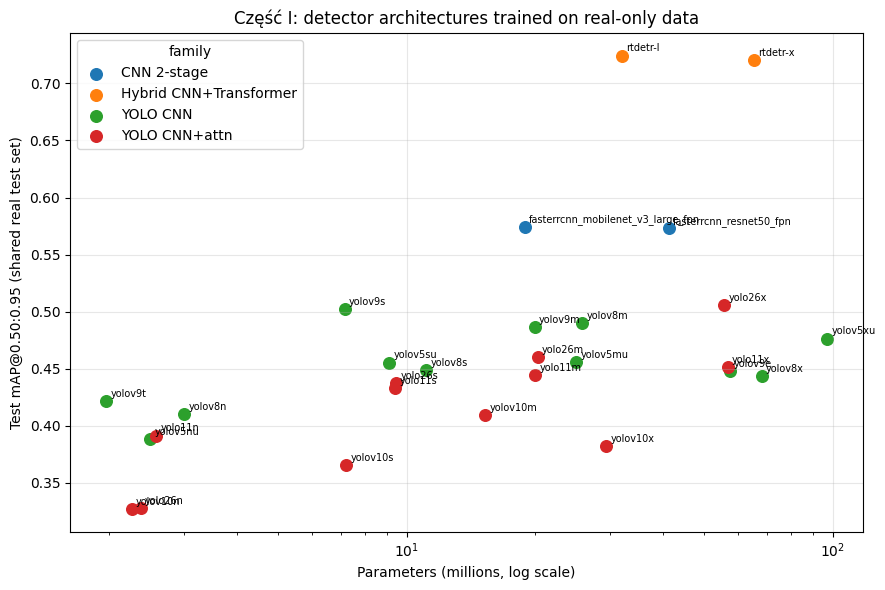

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(PART1_RESULTS)

# Stand-in for the headline "mAP vs Activation-Box Ratio" scatter until ABR is implemented:
# mAP vs model size, colored by architecture family. Already reveals the within-family
# scaling axis and (once the non-YOLO rows are appended) the cross-family separation.
fig, ax = plt.subplots(figsize=(9, 6))
for fam, g in df.groupby('family'):
    ax.scatter(g['params_M'], g['mAP_50_95'], s=70, label=fam)
    for _, r in g.iterrows():
        ax.annotate(r['model'], (r['params_M'], r['mAP_50_95']),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xscale('log')
ax.set_xlabel('Parameters (millions, log scale)')
ax.set_ylabel('Test mAP@0.50:0.95 (shared real test set)')
ax.set_title('Część I: detector architectures trained on real-only data')
ax.legend(title='family')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Scatter plot for mAP vs ABR

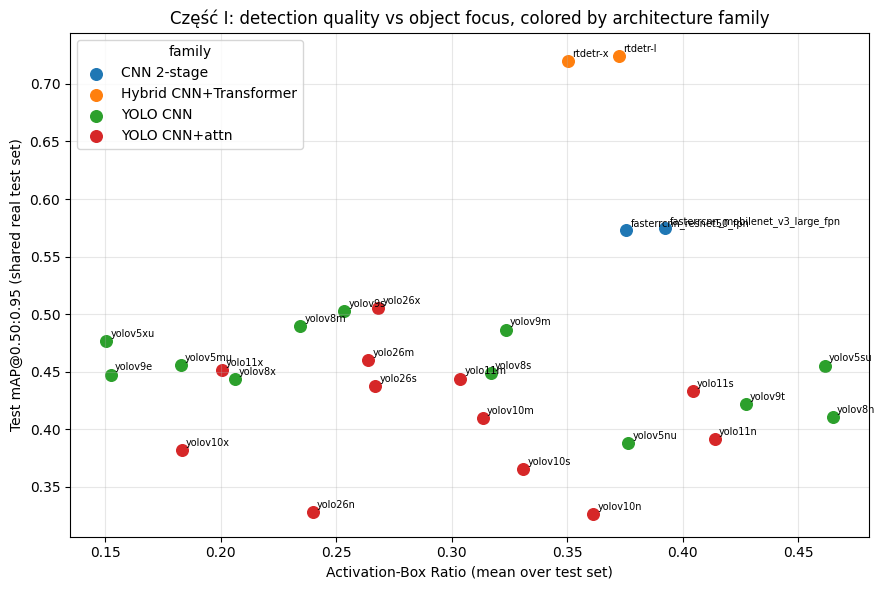

In [58]:
# ===== Część I: headline scatter — detection quality (mAP) vs object focus (ABR) =====
import matplotlib.pyplot as plt

ABR_COL = 'abr_mean'   # switch to 'abr_median' for the outlier-robust version

fig, ax = plt.subplots(figsize=(9, 6))
for fam, g in df_abr.groupby('family'):
    ax.scatter(g[ABR_COL], g['mAP_50_95'], s=70, label=fam)
    for _, r in g.iterrows():
        ax.annotate(r['model'], (r[ABR_COL], r['mAP_50_95']),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel(f"Activation-Box Ratio ({ABR_COL.replace('abr_', '')} over test set)")
ax.set_ylabel('Test mAP@0.50:0.95 (shared real test set)')
ax.set_title('Część I: detection quality vs object focus, colored by architecture family')
ax.legend(title='family')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
# ===== Część I: EigenCAM cross-check ABR for the transformers (DETR / YOLOS) =====
# Primary transformer ABR uses NATIVE attention (abr_mean/abr_median in df_abr). This adds an
# EigenCAM-on-features ABR for the same models, so we can quantify the method confound:
# if attention-ABR ~= EigenCAM-ABR within a model, mixing methods on the scatter is safe.
# (RT-DETR is skipped here - it has no transformer_runs checkpoint and already uses EigenCAM as primary.)
import os
import numpy as np
import pandas as pd
import torch

xcheck_rows = []
for row in PART1_RESULTS:
    run = f"part1_{row['model']}_real_only"
    if not os.path.exists(os.path.join(PROJECT_DIR, 'transformer_runs', run, 'best.pt')):
        continue

    model, processor, model_type = _load_transformer(run)
    _, _, cam_fn_xcheck = _transformer_fns(model, processor, model_type)
    mean, median, n = test_abr_stats(cam_fn_xcheck, key='mean')
    xcheck_rows.append({
        'model': row['model'],
        'abr_eigencam_mean': mean,
        'abr_eigencam_median': median,
    })
    print(f"{row['model']:34} attention ABR vs EigenCAM ABR -> eigencam mean={mean:.3f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if xcheck_rows:
    df_x = pd.DataFrame(xcheck_rows)
    df_abr = df_abr.merge(df_x, on='model', how='left')
    df_abr.to_csv(os.path.join(PROJECT_DIR, 'part1_abr.csv'), index=False)
    print(f"\nadded EigenCAM cross-check ABR for {len(df_x)} transformer(s)")
else:
    print("no transformer checkpoints found - train DETR/YOLOS (and re-run the ABR table) first")

df_abr

no transformer checkpoints found - train DETR/YOLOS (and re-run the ABR table) first


,model,family,params_M,mAP_50,mAP_50_95,abr_mean,abr_median,n_images
0,rtdetr-l,Hybrid CNN+Transformer,31.996070,0.915044,0.724496,0.372300,0.380691,100
1,rtdetr-x,Hybrid CNN+Transformer,65.479766,0.914640,0.720150,0.350174,0.366267,100
2,fasterrcnn_mobilenet_v3_large_fpn,CNN 2-stage,18.955854,0.879273,0.574489,0.392487,0.427524,100
3,fasterrcnn_resnet50_fpn,CNN 2-stage,41.324786,0.864155,0.573014,0.375582,0.384152,100
4,yolo26x,YOLO CNN+attn,55.640478,0.788379,0.505388,0.268112,0.266760,100
5,yolov9s,YOLO CNN,7.169410,0.806398,0.502314,0.253447,0.248580,100
6,yolov8m,YOLO CNN,25.843234,0.789042,0.489579,0.234344,0.213983,100
7,yolov9m,YOLO CNN,20.017330,0.796103,0.486508,0.323330,0.316572,100
8,yolov5xu,YOLO CNN,97.158386,0.768560,0.476282,0.150377,0.135697,100
9,yolo26m,YOLO CNN+attn,20.354078,0.773594,0.460293,0.263822,0.262920,100


In [ ]:
# all models, ordered by test mAP (falls back to whatever runs are on disk if df_part1 isn't defined)
try:
    _runs = [f"part1_{m}_real_only" for m in
             df_part1.sort_values('mAP_50_95', ascending=False)['model']]
except NameError:
    import glob
    _runs = [os.path.basename(p) for p in
             sorted(glob.glob(os.path.join(PROJECT_DIR, 'yolo_runs', 'part1_*'))
                   + glob.glob(os.path.join(PROJECT_DIR, 'frcnn_runs', 'part1_*')))]

show_cam_grid(_runs, sample_idx=0)

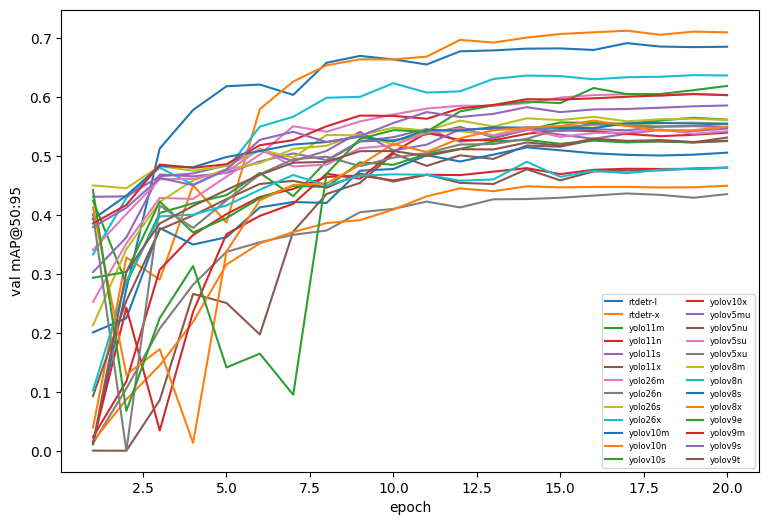

In [60]:
import pandas as pd, matplotlib.pyplot as plt
cur = pd.read_csv(f'{PROJECT_DIR}/part1_training_curves.csv')
fig, ax = plt.subplots(figsize=(9,6))
for run, g in cur.groupby('run'):
    ax.plot(g['epoch'], g['metrics/mAP50-95(B)'], label=run.replace('part1_','').replace('_real_only',''))
ax.set_xlabel('epoch')
ax.set_ylabel('val mAP@50:95')
ax.legend(fontsize=6, ncol=2)
plt.show()

# Transformer Models

### Utility functions for Visualizing Attention Maps
Unlike DETR, which has cross-attention between a CNN encoder and a transformer decoder, YOLOS is a pure Vision Transformer. It appends `[DET]` (detection) tokens to the sequence of image patches. To see where the model is looking for each object, we visualize the self-attention weights between these `[DET]` tokens and the original image patches in the final layer.

In [61]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
from torchvision.transforms.functional import to_pil_image

# --- Helper Functions ---
def get_ground_truth_dict(target, w, h):
    """Converts normalized YOLO ground truth boxes back to absolute pixel coordinates."""
    boxes = target['boxes']
    unnorm_boxes = boxes * torch.tensor([w, h, w, h], dtype=torch.float32)
    cx, cy, bw, bh = unnorm_boxes.unbind(-1)
    xmin = cx - 0.5 * bw
    ymin = cy - 0.5 * bh
    xmax = cx + 0.5 * bw
    ymax = cy + 0.5 * bh
    abs_boxes = torch.stack([xmin, ymin, xmax, ymax], dim=-1)

    cls_key = 'class_labels' if 'class_labels' in target else 'labels'
    return {
        "boxes": abs_boxes.cpu(),
        "labels": target[cls_key].cpu()
    }

def format_image_for_drawing(pixel_values):
    """Formats the raw tensor image for matplotlib and torchvision utilities."""
    img_plot = np.transpose(pixel_values.cpu().numpy()[0], (1, 2, 0))
    img_plot = (img_plot - img_plot.min()) / (img_plot.max() - img_plot.min())

    img_uint8 = (img_plot * 255).astype(np.uint8)
    img_tensor_uint8 = torch.from_numpy(img_uint8).permute(2, 0, 1)
    return img_plot, img_tensor_uint8

def plot_yolos_attentions(img_display, img_plot, attention_mean, queries_kept, num_queries, feature_map_h, feature_map_w, w, h):
    """Plots the original image along with the attention maps for the kept DET tokens."""
    num_boxes_to_show = min(len(queries_kept), 5)
    fig, axes = plt.subplots(1, num_boxes_to_show + 1, figsize=(16, 5))
    if num_boxes_to_show == 1:
        axes = [axes]

    axes[0].imshow(to_pil_image(img_display))
    axes[0].set_title("Original Image with BBoxes")
    axes[0].axis("off")

    for idx, query_idx in enumerate(queries_kept[:num_boxes_to_show]):
        # Row corresponding to the specific [DET] token's attention to all other tokens
        det_token_idx = -num_queries + query_idx.item()

        # Columns corresponding to the image patches
        patch_start_idx = 1
        patch_end_idx = 1 + feature_map_h * feature_map_w

        attn_map = attention_mean[det_token_idx, patch_start_idx:patch_end_idx].reshape(feature_map_h, feature_map_w).cpu().numpy()
        attn_map_resized = cv2.resize(attn_map, (w, h))

        ax = axes[idx + 1]
        ax.imshow(img_plot)
        ax.imshow(attn_map_resized, cmap='jet', alpha=0.5)
        ax.set_title(f"DET Token {query_idx.item()} Attention")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [62]:
def visualize_transformer_attentions(model, processor, dataset, sample_idx, device, model_type='yolos', conf_threshold=0.5):
    """Visualize native attention maps for HF transformer detectors (DETR and YOLOS).
    Uses the shared _forward_with_attentions / _transformer_query_attention helpers."""
    pixel_values, target = dataset[sample_idx]
    pixel_values = pixel_values.unsqueeze(0).to(device)
    outputs = _forward_with_attentions(model, pixel_values)

    # Find predictions above our confidence threshold
    probas = outputs.logits.softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > conf_threshold
    queries_kept = keep.nonzero().squeeze(-1)

    if len(queries_kept) == 0:
        print(f"No objects detected with confidence > {conf_threshold} in this sample.")
        return

    # Setup image for drawing
    h, w = pixel_values.shape[-2:]
    img_plot, img_tensor_uint8 = format_image_for_drawing(pixel_values)

    # Post-process predictions to absolute coordinates
    target_sizes = torch.tensor([[h, w]]).to(device)
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=conf_threshold)[0]

    true_target_for_draw = get_ground_truth_dict(target, w, h)
    pred_for_draw = {
        "boxes": results["boxes"].cpu(),
        "labels": results["labels"].cpu(),
        "scores": results["scores"].cpu()
    }

    # Draw using our utility functions
    img_display = draw_target(img_tensor_uint8, true_target_for_draw)
    img_display = draw_predictions(img_display, pred_for_draw)

    num_boxes_to_show = min(len(queries_kept), 5)

    # 1. Plot the original image with bounding boxes separately (larger)
    plt.figure(figsize=(10, 8))
    plt.imshow(to_pil_image(img_display))
    plt.title("Original Image with BBoxes")
    plt.axis("off")
    plt.show()

    # 2. Plot the attention maps in a separate row
    fig, axes = plt.subplots(1, num_boxes_to_show, figsize=(4 * num_boxes_to_show, 4))
    if num_boxes_to_show == 1:
        axes = [axes]

    # Shared per-query attention extraction, then a single plotting loop
    maps, _, _ = _transformer_query_attention(outputs, model_type, h, w)
    title_prefix = "DET Token" if model_type == 'yolos' else "Query"

    for idx, query_idx in enumerate(queries_kept[:num_boxes_to_show]):
        attn_map = maps[query_idx.item()].cpu().numpy()
        attn_map_resized = cv2.resize(attn_map, (w, h))
        ax = axes[idx]
        ax.imshow(img_plot)
        ax.imshow(attn_map_resized, cmap='jet', alpha=0.5)
        ax.set_title(f"{title_prefix} {query_idx.item()} Attention")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## CNN-backbone + Transformer-based Detection: DETR
Let's use Hugging Face's `transformers` library to fine-tune a DETR model. DETR uses a ResNet backbone to extract features and a Transformer encoder-decoder architecture to predict bounding boxes directly.

In [80]:
from transformers import DetrImageProcessor, DetrForObjectDetection
import torch
import numpy as np
from PIL import Image
import torch.optim as optim
import time
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import random_split, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR


processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", size=TFM_SIZE)

class DETRDataset(DimoDetectionDataset): # Inheriting from our original dataset!
    def __init__(self, native_dimo_ds, image_set, processor):
        # Call the parent init to handle all the 3D-to-2D bounding box projections
        super().__init__(native_dimo_ds, image_set)
        self.processor = processor

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = Image.open(sample['img_path']).convert("RGB")

        annotations = {'image_id': idx, 'annotations': []}

        # Parent class stores bboxes as a tensor: [xmin, ymin, xmax, ymax]
        for box, label in zip(sample['bboxes'], sample['labels']):
            xmin, ymin, xmax, ymax = box.tolist()
            annotations['annotations'].append({
                'bbox': [xmin, ymin, xmax - xmin, ymax - ymin],
                'category_id': label.item(),
                'area': (xmax - xmin) * (ymax - ymin),
                'iscrowd': 0
            })

        encoding = self.processor(images=image, annotations=annotations, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze() # remove batch dim
        target = encoding["labels"][0]
        return pixel_values, target

def detr_collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    encoding = processor.pad(pixel_values, return_tensors="pt")
    labels = [item[1] for item in batch]
    return {'pixel_values': encoding['pixel_values'], 'pixel_mask': encoding['pixel_mask'], 'labels': labels}


In [81]:
# Initialize DETR Datasets and DataLoaders
detr_train_dataset = DETRDataset(dimo_ds, regimes['real_only'], processor)
detr_test_dataset = DETRDataset(dimo_ds, df_real_test, processor)

# Split train dataset
train_size_detr = int(0.8 * len(detr_train_dataset))
val_size_detr = len(detr_train_dataset) - train_size_detr
detr_train_ds, detr_val_ds = torch.utils.data.random_split(detr_train_dataset, [train_size_detr, val_size_detr], generator=torch.Generator().manual_seed(RANDOM_SEED))

DETR_BATCH_SIZE=32

detr_train_loader = DataLoader(detr_train_ds, batch_size=DETR_BATCH_SIZE, shuffle=True, collate_fn=detr_collate_fn, num_workers=2)
detr_val_loader = DataLoader(detr_val_ds, batch_size=DETR_BATCH_SIZE, shuffle=False, collate_fn=detr_collate_fn, num_workers=2)
detr_test_loader = DataLoader(detr_test_dataset, batch_size=DETR_BATCH_SIZE, shuffle=False, collate_fn=detr_collate_fn, num_workers=2)


In [88]:
# Load DETR model with correct number of labels
id2label = {i: f"obj{i}" for i in range(1, NUM_CLASSES)}
id2label[0] = "background"
label2id = {v: k for k, v in id2label.items()}

model_detr = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    revision="no_timm", # Avoid timm warnings
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True, attn_implementation="eager"
).to(device)

optimizer_detr = torch.optim.AdamW(model_detr.parameters(), lr=1e-4, weight_decay=1e-4)

Some weights of DetrForObjectDetection were not initialized from the model checkpoint at facebook/detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.weight: found shape torch.Size([92, 256]) in the checkpoint and torch.Size([8, 256]) in the model instantiated
- class_labels_classifier.bias: found shape torch.Size([92]) in the checkpoint and torch.Size([8]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Train DETR (slow)
To skip training just jump to the section 'Load DETR Model from Checkpoint' below

In [89]:
num_epochs_detr = 30
scheduler_detr = CosineAnnealingLR(optimizer_detr, T_max=num_epochs_detr, eta_min=1e-6)

detr_results = run_hf_transformer_experiment(
    model=model_detr,
    processor=processor,
    optimizer=optimizer_detr,
    train_loader=detr_train_loader,
    val_loader=detr_val_loader,
    test_loader=detr_test_loader,
    run_name='detr_resnet50_dimo_real_only',
    num_epochs=num_epochs_detr,
    lr_scheduler=scheduler_detr
)


========== Starting HF Transformer Experiment: detr_resnet50_dimo_real_only ==========


Epoch [1/30] | Time: 14.9s | Train Loss: 3.1324 | Val Loss: 2.4330 | Val mAP: 0.0119


Epoch [2/30] | Time: 12.8s | Train Loss: 2.4354 | Val Loss: 2.2892 | Val mAP: 0.0210


Epoch [3/30] | Time: 12.7s | Train Loss: 2.3370 | Val Loss: 2.1918 | Val mAP: 0.0282


Epoch [4/30] | Time: 12.9s | Train Loss: 2.2678 | Val Loss: 2.1852 | Val mAP: 0.0387


...

Epoch [29/30] | Time: 13.2s | Train Loss: 1.6567 | Val Loss: 1.6571 | Val mAP: 0.1225


Epoch [30/30] | Time: 13.5s | Train Loss: 1.6622 | Val Loss: 1.6564 | Val mAP: 0.1220

--- Running Independent Test Set Evaluation ---



--- TIDE error analysis: detr_resnet50_dimo_real_only ---
-- detr_resnet50_dimo_real_only_pred --

bbox AP @ 50: 23.55

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     2.94     5.42     0.70    18.17     0.03     0.53  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP      58.30       4.62  



/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['FP', 'FN'])


Test Loss: 1.7974
Test mAP (IoU=0.50:0.95): 0.1132
Test mAP@0.50:            0.2354


In [90]:
# --- Część I integration: record DETR into the unified table + resolver-discoverable checkpoint ---
detr_n_params_M = sum(p.numel() for p in model_detr.parameters()) / 1e6
record_result(PART1_RESULTS, 'detr_resnet50', 'Hybrid CNN+Transformer', detr_results, detr_n_params_M)
_detr_ckpt_dir = os.path.join(PROJECT_DIR, 'transformer_runs', 'part1_detr_resnet50_real_only')
os.makedirs(_detr_ckpt_dir, exist_ok=True)
torch.save({'model_state_dict': model_detr.state_dict()}, os.path.join(_detr_ckpt_dir, 'best.pt'))
print(f"recorded detr_resnet50 into PART1_RESULTS ({detr_n_params_M:.1f}M params) + saved checkpoint")

recorded detr_resnet50 into PART1_RESULTS (41.5M params) + saved checkpoint


### Save DETR model

In [ ]:
detr_save_path = os.path.join(models_dir, 'detr_resnet50_dimo_real_only_epoch_10_checkpoint.pth')
detr_checkpoint = {
    'epoch': num_epochs_detr,
    'model_state_dict': model_detr.state_dict(),
    'optimizer_state_dict': optimizer_detr.state_dict(),
    'scheduler_state_dict': scheduler_detr.state_dict()
}
torch.save(detr_checkpoint, detr_save_path)

### Load DETR Model from Checkpoint

In [ ]:
!mkdir -p /content/models_ckpt
!gdown 1mSY82WBlNjGj7llLBZhQlnvI70PBa15u -O /content/models_ckpt/detr_resnet50_dimo_real_only_epoch_10_checkpoint.pth

In [ ]:
detr_load_path = "/content/models_ckpt/detr_resnet50_dimo_real_only_epoch_10_checkpoint.pth"

# 1. Re-initialize the model architecture
model_detr = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    revision="no_timm",
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True, attn_implementation="eager"
).to(device)

# 2. Re-initialize optimizer and scheduler with the new model's parameters
optimizer_detr = torch.optim.AdamW(model_detr.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_detr = CosineAnnealingLR(optimizer_detr, T_max=num_epochs_detr, eta_min=1e-6)

# 3. Load the checkpoint states
checkpoint = torch.load(detr_load_path, map_location=device)

model_detr.load_state_dict(checkpoint['model_state_dict'])
optimizer_detr.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler_detr.load_state_dict(checkpoint['scheduler_state_dict'])

### Visualizing DETR Cross-Attention Maps
DETR's transformer decoder attends to specific parts of the image feature map when predicting each bounding box. By extracting these cross-attention weights, we can visually inspect exactly where the model is looking for each object.

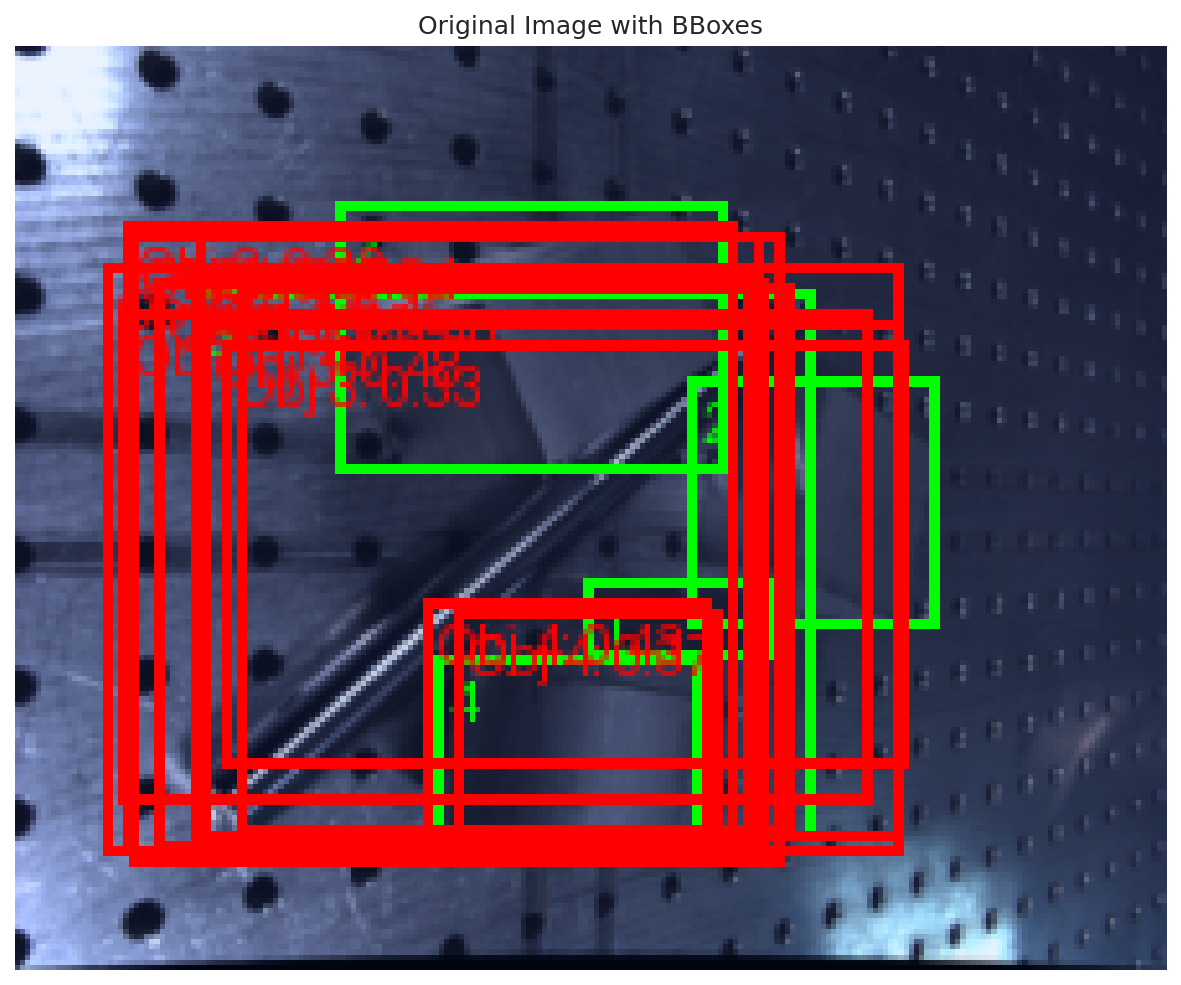

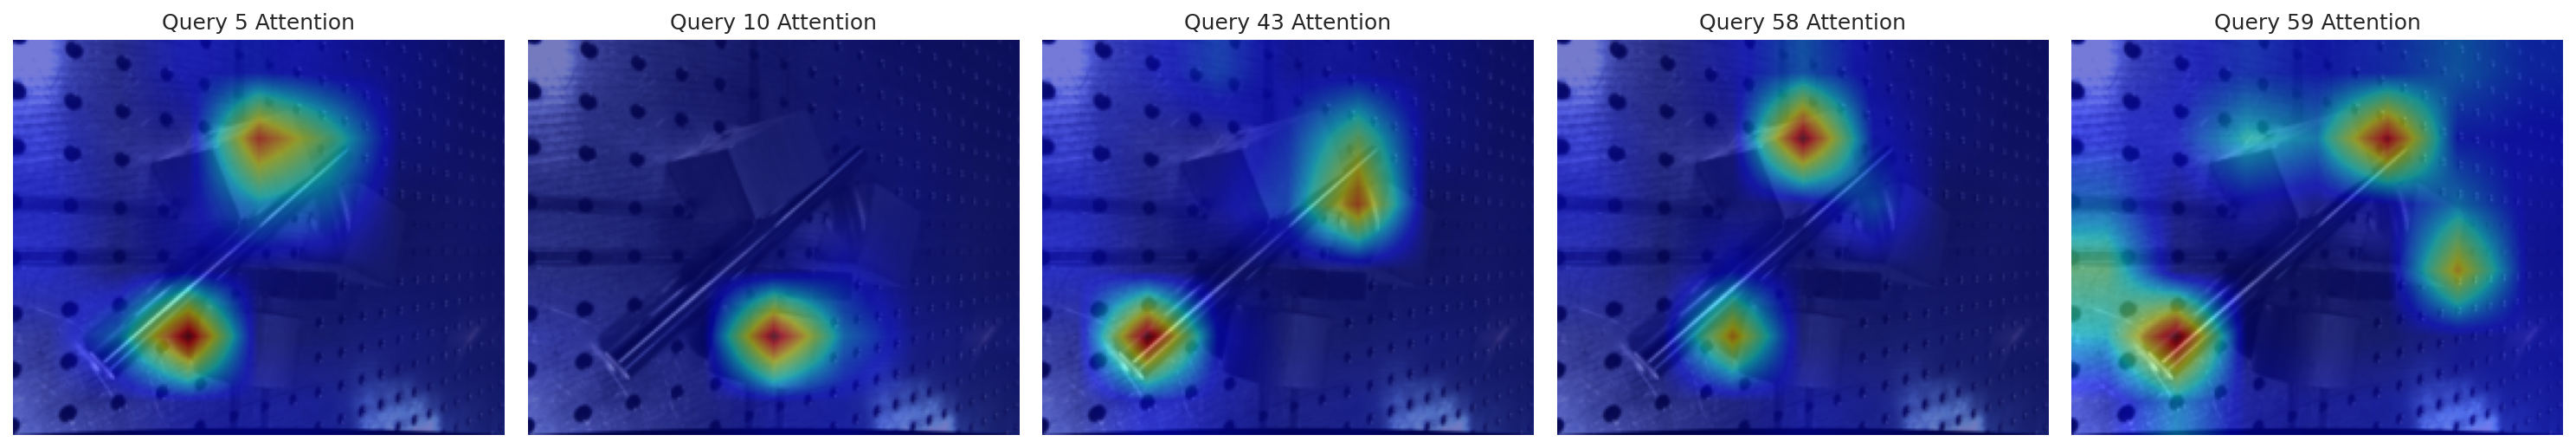

In [93]:
visualize_transformer_attentions(
    model=model_detr,
    processor=processor,
    dataset=detr_val_ds,
    sample_idx=0,
    device=device,
    model_type='detr',
    conf_threshold=0.3
)

## Pure Transformer Detection: YOLOS
Unlike DETR, which uses a ResNet (CNN) backbone to extract features before the transformer, **YOLOS** (You Only Look at One Sequence) uses a pure Vision Transformer (ViT). It splits the image into patches and processes them entirely using self-attention.

In [75]:
from transformers import YolosImageProcessor, YolosForObjectDetection
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import torch

# 1. Load the pure-ViT YOLOS processor
yolos_processor = YolosImageProcessor.from_pretrained("hustvl/yolos-small", size=TFM_SIZE)

# 2. Reuse our DETRDataset since YOLOS uses the exact same COCO-style target format!
yolos_train_dataset = DETRDataset(dimo_ds, regimes['real_only'], yolos_processor)

def yolos_collate_fn(batch):
    pixel_values = [item[0] for item in batch]

    # Images have variable sizes depending on aspect ratio, pad to max in batch
    max_h = max(p.shape[1] for p in pixel_values)
    max_w = max(p.shape[2] for p in pixel_values)

    padded_pixel_values = []
    for p in pixel_values:
        # pad format: (left, right, top, bottom)
        pad_w = max_w - p.shape[2]
        pad_h = max_h - p.shape[1]
        padded_pixel_values.append(torch.nn.functional.pad(p, (0, pad_w, 0, pad_h)))

    pixel_values = torch.stack(padded_pixel_values)
    labels = [item[1] for item in batch]
    return {'pixel_values': pixel_values, 'labels': labels}

yolos_train_loader = DataLoader(yolos_train_dataset, batch_size=8, shuffle=True, collate_fn=yolos_collate_fn, num_workers=2)

# 3. Load the YOLOS model (Swapping out the original classification head for our 7 classes)
model_yolos = YolosForObjectDetection.from_pretrained(
    "hustvl/yolos-small",
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True, attn_implementation="eager"
).to(device)

optimizer_yolos = torch.optim.AdamW(model_yolos.parameters(), lr=1e-4, weight_decay=1e-4)

Some weights of YolosForObjectDetection were not initialized from the model checkpoint at hustvl/yolos-small and are newly initialized because the shapes did not match:
- class_labels_classifier.layers.2.bias: found shape torch.Size([92]) in the checkpoint and torch.Size([8]) in the model instantiated
- class_labels_classifier.layers.2.weight: found shape torch.Size([92, 384]) in the checkpoint and torch.Size([8, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [76]:
import torch
from torch.utils.data import DataLoader

# 1. Create a validation split for YOLOS so we can evaluate mAP during training
train_size_yolos = int(0.8 * len(yolos_train_dataset))
val_size_yolos = len(yolos_train_dataset) - train_size_yolos
yolos_train_ds, yolos_val_ds = torch.utils.data.random_split(
    yolos_train_dataset,
    [train_size_yolos, val_size_yolos],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

# Create a test dataset for YOLOS
yolos_test_dataset = DETRDataset(dimo_ds, df_real_test, yolos_processor)

YOLOS_BATCH_SIZE = 32

# Override the train loader to use the split, and create the val and test loaders
yolos_train_loader = DataLoader(yolos_train_ds, batch_size=YOLOS_BATCH_SIZE, shuffle=True, collate_fn=yolos_collate_fn, num_workers=2)
yolos_val_loader = DataLoader(yolos_val_ds, batch_size=YOLOS_BATCH_SIZE, shuffle=False, collate_fn=yolos_collate_fn, num_workers=2)
yolos_test_loader = DataLoader(yolos_test_dataset, batch_size=YOLOS_BATCH_SIZE, shuffle=False, collate_fn=yolos_collate_fn, num_workers=2)

In [77]:
num_epochs_yolos = 10
scheduler_yolos = CosineAnnealingLR(optimizer_yolos, T_max=num_epochs_yolos, eta_min=1e-6)

yolos_results = run_hf_transformer_experiment(
    model=model_yolos,
    processor=yolos_processor,
    optimizer=optimizer_yolos,
    train_loader=yolos_train_loader,
    val_loader=yolos_val_loader,
    test_loader=yolos_test_loader,
    run_name='yolos_small_dimo_real_only',
    num_epochs=num_epochs_yolos,
    lr_scheduler=scheduler_yolos
)


========== Starting HF Transformer Experiment: yolos_small_dimo_real_only ==========


Epoch [1/10] | Time: 18.0s | Train Loss: 3.4960 | Val Loss: 2.4900 | Val mAP: 0.0169


Epoch [2/10] | Time: 19.8s | Train Loss: 2.3879 | Val Loss: 2.1734 | Val mAP: 0.0465


Epoch [3/10] | Time: 18.4s | Train Loss: 2.1104 | Val Loss: 1.9911 | Val mAP: 0.0531


Epoch [4/10] | Time: 19.0s | Train Loss: 1.8672 | Val Loss: 1.7480 | Val mAP: 0.0933


...

Epoch [9/10] | Time: 18.8s | Train Loss: 1.2656 | Val Loss: 1.4814 | Val mAP: 0.1830


Epoch [10/10] | Time: 18.8s | Train Loss: 1.2144 | Val Loss: 1.4815 | Val mAP: 0.1864

--- Running Independent Test Set Evaluation ---



--- TIDE error analysis: yolos_small_dimo_real_only ---
-- yolos_small_dimo_real_only_pred --

bbox AP @ 50: 38.62

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     1.21     8.13     1.03    15.09     0.23     0.52  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP      51.32       3.53  



/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['FP', 'FN'])


Test Loss: 1.5627
Test mAP (IoU=0.50:0.95): 0.1709
Test mAP@0.50:            0.3861


In [78]:
yolos_n_params_M = sum(p.numel() for p in model_yolos.parameters()) / 1e6
record_result(PART1_RESULTS, 'yolos_small', 'Transformer (ViT)', yolos_results, yolos_n_params_M)
_yolos_ckpt_dir = os.path.join(PROJECT_DIR, 'transformer_runs', 'part1_yolos_small_real_only')
os.makedirs(_yolos_ckpt_dir, exist_ok=True)
torch.save({'model_state_dict': model_yolos.state_dict()}, os.path.join(_yolos_ckpt_dir, 'best.pt'))
print(f"recorded yolos_small into PART1_RESULTS ({yolos_n_params_M:.1f}M params) + saved checkpoint")

recorded yolos_small into PART1_RESULTS (30.7M params) + saved checkpoint


### Save YOLOS Model

In [ ]:
yolos_save_path = os.path.join(models_dir, 'yolos_small_dimo_real_only_epoch_5_checkpoint.pth')
yolos_checkpoint = {
    'epoch': num_epochs_yolos,
    'model_state_dict': model_yolos.state_dict(),
    'optimizer_state_dict': optimizer_yolos.state_dict(),
    'scheduler_state_dict': scheduler_yolos.state_dict()
}
torch.save(yolos_checkpoint, yolos_save_path)


### Load YOLOS Model from Checkpoint
To load the model, we instantiate the base model again and load the weights from our saved `model_state_dict`.

In [ ]:
!mkdir -p /content/models_ckpt
!gdown 1DNJxxA4eqW87vcg9RFvhgjCplZcHtclg -O /content/models_ckpt/yolos_small_dimo_real_only_epoch_5_checkpoint.pth

In [ ]:
yolos_save_path = "/content/models_ckpt/yolos_small_dimo_real_only_epoch_5_checkpoint.pth"

# 1. Re-initialize the model architecture
model_yolos = YolosForObjectDetection.from_pretrained(
    "hustvl/yolos-small",
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True, attn_implementation="eager"
).to(device)

# 2. Re-initialize optimizer and scheduler with the new model's parameters
optimizer_yolos = torch.optim.AdamW(model_yolos.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_yolos = CosineAnnealingLR(optimizer_yolos, T_max=num_epochs_yolos, eta_min=1e-6)

# 3. Load the checkpoint states
checkpoint = torch.load(yolos_save_path, map_location=device)

model_yolos.load_state_dict(checkpoint['model_state_dict'])
optimizer_yolos.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler_yolos.load_state_dict(checkpoint['scheduler_state_dict'])

### YOLOS attn-maps

/usr/local/lib/python3.12/dist-packages/torchvision/utils.py:375: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


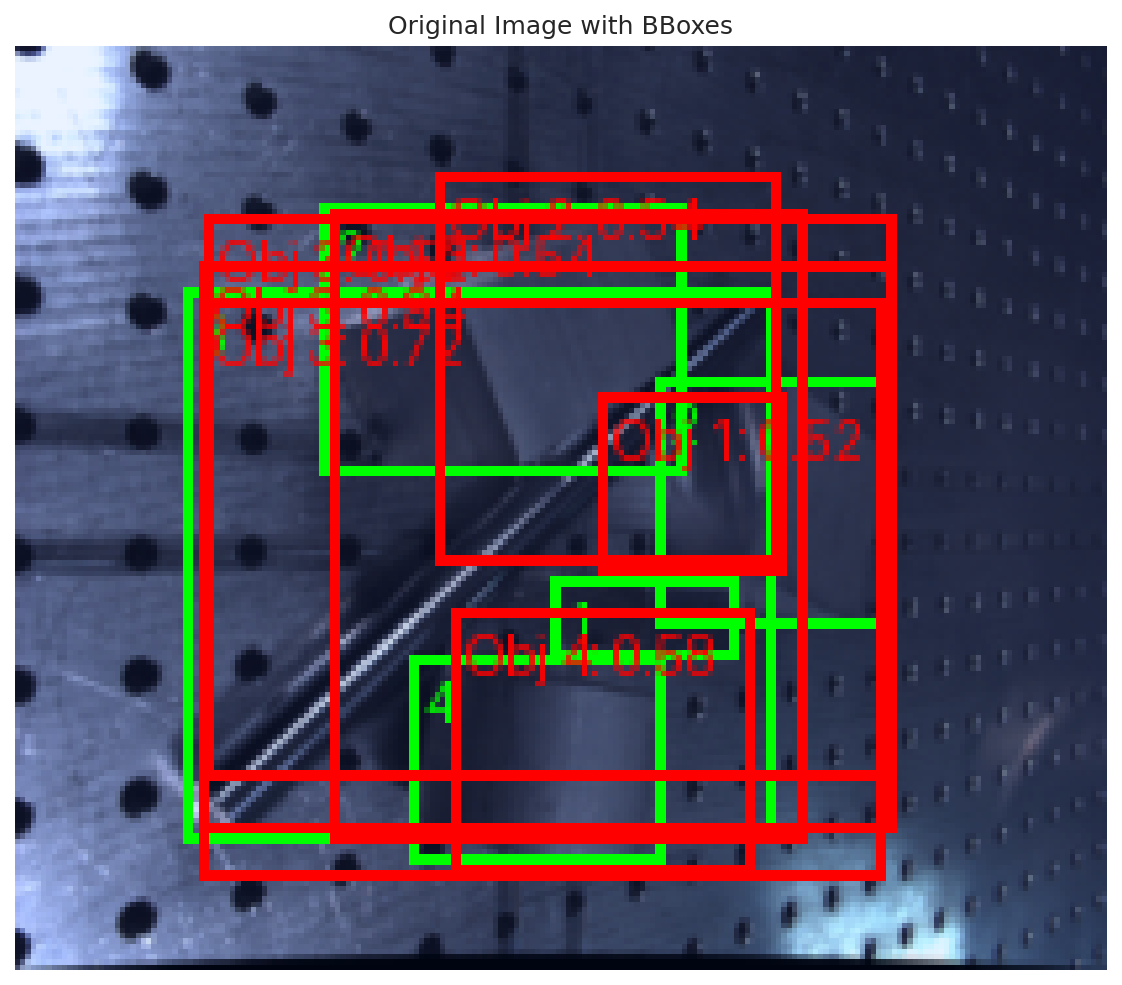

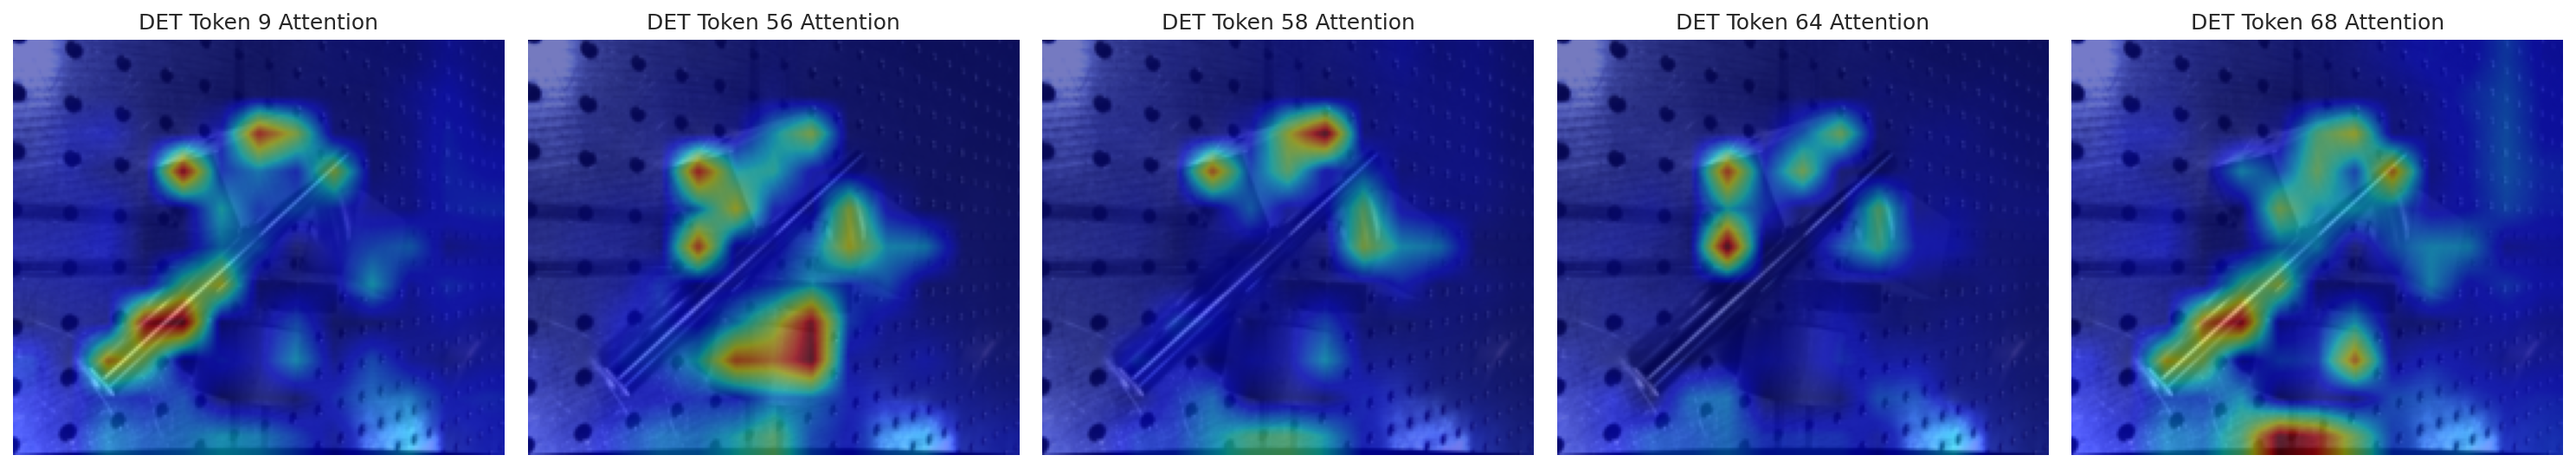

In [79]:
visualize_transformer_attentions(
    model=model_yolos,
    processor=yolos_processor,
    dataset=yolos_val_ds,
    sample_idx=0,
    device=device,
    model_type='yolos',
    conf_threshold=0.5
)

# Tensorboard Train/Val/Test Metrics Visualization

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir {PROJECT_DIR}

# Optional: archive PROJECT_DIR to Google Drive

All computation runs on local `/content` disk, which Colab wipes when the session ends. Run the archive cell to tar the whole `PROJECT_DIR` (models, runs, results, yolo dataset) into one file on Drive — a single fast sequential write instead of many slow small-file writes. Use the restore cell next session to bring it back.

Archive local PROJECT_DIR -> Google Drive (run when you want to persist a snapshot)


In [ ]:
import os, tarfile, time

snapshot = os.path.join(DRIVE_DIR, f"project_snapshot_{time.strftime('%Y%m%d_%H%M%S')}.tar")
with tarfile.open(snapshot, 'w', dereference=True) as tar:  # dereference -> store real files, not symlinks
    tar.add(PROJECT_DIR, arcname=os.path.basename(PROJECT_DIR))